# **1. Business Understanding / Бизнес-анализ: описание кейса**

Владелец небольшой сети кофеен планирует расширить свой бизнес и открыть несколько новых точек в течение ближайших 4 месяцев. В связи с этим он хочет понять, как распределяются продажи по существующей сети кофеен, какие виды продукции вносят наибольший вклад в объем продаж, а от каких, возможно, стоит отказаться, кто является основным клиентом сети.
Заказчик предоставил датасет в формате csv с выгрузкой о транзакциях и клиентах из его CRM-системы.


**Моя задача** - Проанализировать полученные данные и представить аналитический отчет, содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения его бизнес-задач.

**Формат файла** по результатам предобработки: *xlsx* или *csv*

Основные пункты проработанного дизайна исследования представлены в **карточке проекта**.

# **2. Data Understanding / Изучение данных**

## 2.1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import json
import scipy
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn.linear_model as lm
import math

In [2]:
# установим размер графиков
sns.set(rc={'figure.figsize': (8, 4)})

## 2.2. Чтение файла

In [3]:
df = pd.read_csv('coffee_shop_hard.csv')

Параметр *sep* не указываем, т.к. по умолчанию sep=',' (что соответствует используемому разделителю в нашем файле)

## 2.3. Обзор датасета

In [4]:
# Установить ширину столбцов на всё содержимое
pd.set_option("display.max_colwidth", None)

In [5]:
df.head()

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
0,0,1,162.50,"{""product_id"":52,""product_name"":""Traditional Blend Chai Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":558,""birthdate"":""1983-02-25"",""gender"":""женский""}"
1,1,2,227.50,"{""product_id"":27,""product_name"":""Brazilian Lg"",""product_category"":""Coffee""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":781,""birthdate"":""1991-07-29"",""gender"":""не указан""}"
2,2,2,162.50,"{""product_id"":46,""product_name"":""Serenity Green Tea Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":788,""birthdate"":""1995-02-23"",""gender"":""не указан""}"
3,3,2,162.50,"{""product_id"":23,""product_name"":""Our Old Time Diner Blend Rg"",""product_category"":""Coffee""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":683,""birthdate"":""1999-02-06"",""gender"":""женский""}"
4,4,1,159.25,"{""product_id"":34,""product_name"":""Jamaican Coffee River Sm"",""product_category"":""Coffee""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":99,""birthdate"":""1967-01-29"",""gender"":""мужской""}"


In [6]:
df.tail()

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
24904,38871,2,195.00,"{""product_id"":47,""product_name"":""Serenity Green Tea Lg"",""product_category"":""Tea""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5786,""birthdate"":""1999-08-20"",""gender"":""не указан""}"
24905,47902,1,130.00,"{""product_id"":22,""product_name"":""Our Old Time Diner Blend Sm"",""product_category"":""Coffee""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5518,""birthdate"":""1952-05-12"",""gender"":""женский""}"
24906,14247,2,243.75,"{""product_id"":38,""product_name"":""Latte"",""product_category"":""Coffee""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5623,""birthdate"":""1984-07-18"",""gender"":""мужской""}"
24907,6891,1,227.50,"{""product_id"":75,""product_name"":""Croissant"",""product_category"":""Bakery""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":186,""birthdate"":""1981-11-16"",""gender"":""мужской""}"
24908,34092,3,162.50,"{""product_id"":46,""product_name"":""Serenity Green Tea Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5632,""birthdate"":""1996-03-28"",""gender"":""не указан""}"


In [7]:
df.sample(5)

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
1655,1655,1,227.50,"{""product_id"":58,""product_name"":""Dark chocolate Rg"",""product_category"":""Drinking Chocolate""}","{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8039,""birthdate"":""1963-11-15"",""gender"":""мужской""}"
6987,6990,1,195.00,"{""product_id"":45,""product_name"":""Peppermint Lg"",""product_category"":""Tea""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":685,""birthdate"":""1999-05-11"",""gender"":""женский""}"
20582,38595,2,243.75,"{""product_id"":38,""product_name"":""Latte"",""product_category"":""Coffee""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":527,""birthdate"":""1979-03-14"",""gender"":""женский""}"
15433,21055,2,243.75,"{""product_id"":38,""product_name"":""Latte"",""product_category"":""Coffee""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5616,""birthdate"":""1985-08-19"",""gender"":""не указан""}"
16718,24630,3,201.50,"{""product_id"":35,""product_name"":""Jamaican Coffee River Rg"",""product_category"":""Coffee""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5134,""birthdate"":""1993-07-20"",""gender"":""мужской""}"


In [8]:
df.shape

(24909, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24909 entries, 0 to 24908
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  24909 non-null  int64  
 1   quantity        24909 non-null  int64  
 2   unit_price      24909 non-null  float64
 3   product_info    24909 non-null  object 
 4   store_info      24909 non-null  object 
 5   customer_info   24909 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.1+ MB


## 2.4. Выявление проблем

1. Возможно наличие дубликатов
2. Наличие вложенных значений (словарей по признакам 'product_info', 'store_info', 'customer_info')
3. Приведение признака 'birthdate' в формат datetime после распаковки
4. Необходимость расчета признака 'age'(возраст) (от признака 'birthdate'), признака 'amount'(сумма транзакции)
5. Наличие названий городов на кириллице и латинице - приведение к единому типу, приведение названий к строчным буквам
6. Возможные другие проблемы, которые могут быть выявлены в процессе предобработки данных

# **3. Data Preparation / Предобработка данных**

## 3.1. Проверка и исключение полных дубликатов

In [10]:
#  создадим копию датафрейма
df_copy = df.copy()

In [11]:
# проверка на количество полных дубликатов
df_copy.duplicated().sum()

np.int64(57)

In [12]:
# проверка дубликатов по столбцу 'transaction_id'
df_copy.duplicated(subset='transaction_id').sum()

np.int64(57)

In [13]:
# исключение полных дубликатов из датафрейма
df_copy.drop_duplicates(inplace=True)

In [14]:
# контроль размеров датафрейма
df_copy.shape

(24852, 6)

## 3.2. Распаковка вложенных структур данных

In [15]:
df_copy.head(3)

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
0,0,1,162.5,"{""product_id"":52,""product_name"":""Traditional Blend Chai Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":558,""birthdate"":""1983-02-25"",""gender"":""женский""}"
1,1,2,227.5,"{""product_id"":27,""product_name"":""Brazilian Lg"",""product_category"":""Coffee""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":781,""birthdate"":""1991-07-29"",""gender"":""не указан""}"
2,2,2,162.5,"{""product_id"":46,""product_name"":""Serenity Green Tea Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":3,""store_city"":""Санкт-Петербург""}","{""customer_id"":788,""birthdate"":""1995-02-23"",""gender"":""не указан""}"


**Необходимо обработать:** 'product_info', 'store_info', 'customer_info'

### 'product_info'

In [16]:
# обзор первого значения по признаку
df_copy['product_info'][0]

'{"product_id":52,"product_name":"Traditional Blend Chai Rg","product_category":"Tea"}'

In [17]:
# проверим тип данных
type(df_copy['product_info'][0])

str

In [18]:
def json_to_product_id(text):
  ''' функция, которая распаковывает id продукта с помощью модуля json
        '''
  res = json.loads(text)['product_id']
  return res

In [19]:
# проверяем работу функции на одном значении
json_to_product_id(df_copy['product_info'][0])

52

In [20]:
# применяем функцию ко всему столбцу
df_copy['product_id'] = df['product_info'].apply(json_to_product_id)

In [21]:
# проверяем результат
df_copy.product_id

0        52
1        27
2        46
3        23
4        34
         ..
24847    41
24848    87
24849    25
24850    44
24851    75
Name: product_id, Length: 24852, dtype: int64

In [22]:
def json_to_product_name(text):
  ''' функция, которая распаковывает название продукта с помощью модуля json
        '''
  res = json.loads(text)['product_name']
  return res

In [23]:
# проверяем работу функции на одном значении
json_to_product_name(df_copy['product_info'][0])

'Traditional Blend Chai Rg'

In [24]:
# применяем функцию ко всему столбцу
df_copy['product_name'] = df['product_info'].apply(json_to_product_name)

In [25]:
# проверяем результат
df_copy.product_name

0          Traditional Blend Chai Rg
1                       Brazilian Lg
2              Serenity Green Tea Rg
3        Our Old Time Diner Blend Rg
4           Jamaican Coffee River Sm
                    ...             
24847                  Cappuccino Lg
24848           Ouro Brasileiro shot
24849                   Brazilian Sm
24850                  Peppermint Rg
24851                      Croissant
Name: product_name, Length: 24852, dtype: object

In [26]:
def json_to_product_category(text):
  ''' функция, которая распаковывает категорию продукта с помощью модуля json
  '''
  res = json.loads(text)['product_category']
  return res

In [27]:
# проверяем работу функции на одном значении
json_to_product_category(df_copy['product_info'][0])

'Tea'

In [28]:
# применяем функцию ко всему столбцу
df_copy['product_category'] = df['product_info'].apply(json_to_product_category)

In [29]:
# проверяем результат
df_copy.product_category

0           Tea
1        Coffee
2           Tea
3        Coffee
4        Coffee
          ...  
24847    Coffee
24848    Coffee
24849    Coffee
24850       Tea
24851    Bakery
Name: product_category, Length: 24852, dtype: object

In [30]:
# Данные записались корректно, на латинице, далее приведем к нижнему регистру, менять на кириллицу не будем.

### 'store_info'

In [31]:
# обзор первого значения по признаку
df_copy['store_info'][0]

'{"sales_outlet_id":3,"store_city":"Санкт-Петербург"}'

In [32]:
# проверим тип данных
type(df_copy['store_info'][0])

str

In [33]:
df_copy['sales_outlet_id'] = df_copy['store_info'].apply(lambda x: eval(x)['sales_outlet_id'])

In [34]:
df_copy['sales_outlet_id']

0        3
1        3
2        3
3        3
4        3
        ..
24847    8
24848    8
24849    8
24850    8
24851    8
Name: sales_outlet_id, Length: 24852, dtype: int64

In [35]:
df_copy['store_city'] = df_copy['store_info'].apply(lambda x: eval(x)['store_city'])

In [36]:
df_copy['store_city']

0        Санкт-Петербург
1        Санкт-Петербург
2        Санкт-Петербург
3        Санкт-Петербург
4        Санкт-Петербург
              ...       
24847             Moscow
24848             Moscow
24849             Moscow
24850             Moscow
24851             Moscow
Name: store_city, Length: 24852, dtype: object

In [37]:
# Данные записались корректно, но присутствуют названия города на латинице,
# далее заменим на кириллицу и приведем к нижнему регистру

### 'customer_info'

In [38]:
# обзор первого значения по признаку
df_copy['customer_info'][0]

'{"customer_id":558,"birthdate":"1983-02-25","gender":"женский"}'

In [39]:
# проверим тип данных
type(df_copy['customer_info'][0])

str

In [40]:
# распакуем customer_id
df_copy['customer_id'] = df_copy['customer_info'].apply(lambda x: json.loads(x)['customer_id'])

In [41]:
# проверяем результат
df_copy['customer_id']

0         558
1         781
2         788
3         683
4          99
         ... 
24847    8026
24848    8401
24849    8412
24850    8030
24851    8030
Name: customer_id, Length: 24852, dtype: int64

In [42]:
# распакуем birthdate
df_copy['birthdate'] = df_copy['customer_info'].apply(lambda x: json.loads(x)['birthdate'])

In [43]:
# проверим результат
df_copy['birthdate']

0        1983-02-25
1        1991-07-29
2        1995-02-23
3        1999-02-06
4        1967-01-29
            ...    
24847    1962-10-25
24848    1954-11-05
24849    1953-09-16
24850    1994-01-10
24851    1994-01-10
Name: birthdate, Length: 24852, dtype: object

In [44]:
# распакуем gender
df_copy['gender'] = df_copy['customer_info'].apply(lambda x: json.loads(x)['gender'])

In [45]:
# проверим
df_copy['gender']

0          женский
1        не указан
2        не указан
3          женский
4          мужской
           ...    
24847      мужской
24848      мужской
24849      мужской
24850      женский
24851      женский
Name: gender, Length: 24852, dtype: object

In [46]:
# данные записались корректно, далее приведем данные birthdate к формату datetime и расчитаем возраст

In [47]:
# проверим колонки
df_copy.columns

Index(['transaction_id', 'quantity', 'unit_price', 'product_info',
       'store_info', 'customer_info', 'product_id', 'product_name',
       'product_category', 'sales_outlet_id', 'store_city', 'customer_id',
       'birthdate', 'gender'],
      dtype='object')

In [48]:
df_copy.sample(3)

,transaction_id,quantity,unit_price,product_info,store_info,customer_info,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,birthdate,gender
9116,9120,1,227.50,"{""product_id"":74,""product_name"":""Ginger Biscotti"",""product_category"":""Bakery""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5782,""birthdate"":""1952-12-05"",""gender"":""женский""}",74,Ginger Biscotti,Bakery,5,Москва,5782,1952-12-05,женский
7315,7318,2,162.50,"{""product_id"":54,""product_name"":""Morning Sunrise Chai Rg"",""product_category"":""Tea""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5104,""birthdate"":""1986-11-26"",""gender"":""мужской""}",54,Morning Sunrise Chai Rg,Tea,5,Москва,5104,1986-11-26,мужской
17135,26493,2,243.75,"{""product_id"":60,""product_name"":""Sustainably Grown Organic Rg"",""product_category"":""Drinking Chocolate""}","{""sales_outlet_id"":5,""store_city"":""Москва""}","{""customer_id"":5062,""birthdate"":""1977-01-11"",""gender"":""женский""}",60,Sustainably Grown Organic Rg,Drinking Chocolate,5,Москва,5062,1977-01-11,женский


In [49]:
# исключим исходные столбцы 'product_info','store_info', 'customer_info'
df_copy.drop(columns=['product_info', 'store_info', 'customer_info'], inplace=True)

In [50]:
# проверка
df_copy.columns

Index(['transaction_id', 'quantity', 'unit_price', 'product_id',
       'product_name', 'product_category', 'sales_outlet_id', 'store_city',
       'customer_id', 'birthdate', 'gender'],
      dtype='object')

## 3.3. Преобразование данных в необходимый формат

In [51]:
# обзор типов данных
df_copy.dtypes

transaction_id        int64
quantity              int64
unit_price          float64
product_id            int64
product_name         object
product_category     object
sales_outlet_id       int64
store_city           object
customer_id           int64
birthdate            object
gender               object
dtype: object

**Необходимо преобразовать**:
1. 'birthdate' - в формат даты и времени datetime

### 'birthdate'

In [52]:
df_copy.birthdate

0        1983-02-25
1        1991-07-29
2        1995-02-23
3        1999-02-06
4        1967-01-29
            ...    
24847    1962-10-25
24848    1954-11-05
24849    1953-09-16
24850    1994-01-10
24851    1994-01-10
Name: birthdate, Length: 24852, dtype: object

In [53]:
# установим нужный формат данных
df_copy.birthdate = pd.to_datetime(df_copy.birthdate)

In [54]:
# контроль
df_copy.birthdate

0       1983-02-25
1       1991-07-29
2       1995-02-23
3       1999-02-06
4       1967-01-29
           ...    
24847   1962-10-25
24848   1954-11-05
24849   1953-09-16
24850   1994-01-10
24851   1994-01-10
Name: birthdate, Length: 24852, dtype: datetime64[ns]

## 3.4. Расчет дополнительных признаков

### 'age'

Для расчета возраста необходимо из текущей даты вычесть значение 'birthdate'

In [55]:
# определим текущую дату
current_day = pd.Timestamp.today()
current_day

Timestamp('2025-10-17 15:13:22.167017')

In [56]:
# вычислим текущий год
current_year = current_day.year
current_year

2025

In [57]:
# рассчитаем значения возраста и сохраним в новый признак 'age'
df_copy['age'] = current_year - df_copy.birthdate.apply(lambda x: x.year)
df_copy.age

0        42
1        34
2        30
3        26
4        58
         ..
24847    63
24848    71
24849    72
24850    31
24851    31
Name: age, Length: 24852, dtype: int64

In [58]:
# исключим исходный столбец 'birthdate'
df_copy.drop(columns='birthdate', inplace=True)

In [59]:
# контроль колонок
df_copy.columns

Index(['transaction_id', 'quantity', 'unit_price', 'product_id',
       'product_name', 'product_category', 'sales_outlet_id', 'store_city',
       'customer_id', 'gender', 'age'],
      dtype='object')

### 'amount'

Для расчета суммы чека 'amount' необходимо умножить количество товара 'quantity' на его стоимость 'unit_price'

In [60]:
df_copy['amount'] = df_copy['quantity'] * df_copy['unit_price']
df_copy.amount

0        162.50
1        455.00
2        325.00
3        325.00
4        159.25
          ...  
24847    276.25
24848    136.50
24849    286.00
24850    325.00
24851    227.50
Name: amount, Length: 24852, dtype: float64

In [61]:
# удалим исходный столбец 'unit_price'
df_copy.drop(columns=['unit_price'], inplace=True)

In [62]:
# контроль колонок
df_copy.columns

Index(['transaction_id', 'quantity', 'product_id', 'product_name',
       'product_category', 'sales_outlet_id', 'store_city', 'customer_id',
       'gender', 'age', 'amount'],
      dtype='object')

## 3.5. Форматирование текстовых данных

**Необходимо отформатировать** следующие признаки:
1.  'store_city'
2. 'product_name'

### 'store_city'

In [63]:
# проверим количество уникальных значений
df_copy.store_city.nunique()

3

In [64]:
# выведем список уникальных значений
df_copy.store_city.unique()

array(['Санкт-Петербург', 'Москва', 'Moscow'], dtype=object)

В датасете 3 уникальных значения признака. Изучив значения, можно выделить **следующие проблемы**:
1.  2 из 3 значений это один и тот же город, написаный на кириллице и латинице. Осуществим замену на кириллицу.
2. названия с заглавной буквы - приведем к строчным.

In [65]:
# приведем названия к строчным буквам
df_copy.store_city = df_copy.store_city.str.lower()
df_copy.store_city

0        санкт-петербург
1        санкт-петербург
2        санкт-петербург
3        санкт-петербург
4        санкт-петербург
              ...       
24847             moscow
24848             moscow
24849             moscow
24850             moscow
24851             moscow
Name: store_city, Length: 24852, dtype: object

In [66]:
# заменим moscow на москва
df_copy.loc[df_copy.store_city == 'moscow', 'store_city'] = 'москва'

In [67]:
# проверим
df_copy.store_city.unique()

array(['санкт-петербург', 'москва'], dtype=object)

### 'product_name'

In [68]:
# проверим количество уникальных значений
df_copy.product_name.nunique()

80

In [69]:
# выведем список уникальных значений
df_copy.product_name.unique()

array(['Traditional Blend Chai Rg', 'Brazilian Lg',
       'Serenity Green Tea Rg', 'Our Old Time Diner Blend Rg',
       'Jamaican Coffee River Sm', 'Ethiopia Rg', 'English Breakfast Lg',
       'Sustainably Grown Organic Rg', 'Earl Grey Lg',
       'Jamaican Coffee River Rg', 'Serenity Green Tea Lg',
       'Brazilian Sm', 'English Breakfast Rg',
       'Traditional Blend Chai Lg', 'Cappuccino', 'Espresso shot',
       'Cappuccino Lg', 'Latte', 'Earl Grey Rg', 'Dark chocolate Lg',
       'Columbian Medium Roast Sm', 'Oatmeal Scone',
       'Morning Sunrise Chai Lg', 'Morning Sunrise Chai Rg',
       'Peppermint Lg', 'Jumbo Savory Scone', 'Lemon Grass Lg',
       'Sustainably Grown Organic Lg', 'Dark chocolate Rg',
       'Lemon Grass Rg', 'Ethiopia Sm', 'Latte Rg',
       'Our Old Time Diner Blend Sm', 'Chocolate Chip Biscotti',
       'Columbian Medium Roast Rg', 'Ethiopia Lg', 'Brazilian Rg',
       'Columbian Medium Roast Lg', 'Spicy Eye Opener Chai Rg',
       'Ginger Biscotti', 

В датасете 80 уникальных значений признака. Изучив значения, можно выделить следующее:
1. все названия с заглавных букв - приведем к строчным.

In [70]:
# приведем названия к строчным буквам
df_copy.product_name = df_copy.product_name.str.lower()
df_copy.product_name

0          traditional blend chai rg
1                       brazilian lg
2              serenity green tea rg
3        our old time diner blend rg
4           jamaican coffee river sm
                    ...             
24847                  cappuccino lg
24848           ouro brasileiro shot
24849                   brazilian sm
24850                  peppermint rg
24851                      croissant
Name: product_name, Length: 24852, dtype: object

### 'product_category'

In [71]:
# проверим количество уникальных значений
df_copy.product_category.nunique()

9

In [72]:
# выведем список уникальных значений
df_copy.product_category.unique()

array(['Tea', 'Coffee', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Coffee beans', 'Loose Tea', 'Packaged Chocolate', 'Branded'],
      dtype=object)

В датасете 9 уникальных значений признака. Изучив значения, можно выделить следующее:
1. все названия с заглавных букв - приведем к строчным.

In [73]:
# приведем названия к строчным буквам
df_copy.product_category = df_copy.product_category.str.lower()
df_copy.product_category

0           tea
1        coffee
2           tea
3        coffee
4        coffee
          ...  
24847    coffee
24848    coffee
24849    coffee
24850       tea
24851    bakery
Name: product_category, Length: 24852, dtype: object

## 3.6. Проверка и сохранение датасета

In [74]:
# обзор размеров датафрейма
df_copy.shape

(24852, 11)

In [75]:
# обзор типов данных, пропущенных значений, диапазона индексов
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24852 entries, 0 to 24851
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    24852 non-null  int64  
 1   quantity          24852 non-null  int64  
 2   product_id        24852 non-null  int64  
 3   product_name      24852 non-null  object 
 4   product_category  24852 non-null  object 
 5   sales_outlet_id   24852 non-null  int64  
 6   store_city        24852 non-null  object 
 7   customer_id       24852 non-null  int64  
 8   gender            24852 non-null  object 
 9   age               24852 non-null  int64  
 10  amount            24852 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 2.8+ MB


In [76]:
# еще раз проверим на дубликаты
df_copy.duplicated().sum()

np.int64(0)

In [77]:
# обзор содержания датасета
df_copy.sample(5)

,transaction_id,quantity,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,gender,age,amount
23835,47871,2,51,earl grey lg,tea,5,москва,5667,не указан,42,390.00
19126,34073,3,24,our old time diner blend lg,coffee,5,москва,5833,женский,35,585.00
9788,9792,1,40,cappuccino,coffee,3,санкт-петербург,437,женский,58,243.75
18643,32569,1,74,ginger biscotti,bakery,8,москва,8077,женский,51,227.50
16325,22848,1,69,hazelnut biscotti,bakery,5,москва,5796,мужской,33,211.25


In [78]:
# удалим признак, который больше не представляет ценности в рамках кейса
df_copy.drop(columns='transaction_id', inplace=True)
df_copy.columns

Index(['quantity', 'product_id', 'product_name', 'product_category',
       'sales_outlet_id', 'store_city', 'customer_id', 'gender', 'age',
       'amount'],
      dtype='object')

In [79]:
# переименуем столбцы
df_copy.rename(columns={'product_name': 'product', 'product_category': 'category',
                        'sales_outlet_id': 'outlet_id', 'store_city': 'city'}, inplace=True)

In [80]:
# контроль
df_copy.head(1)

,quantity,product_id,product,category,outlet_id,city,customer_id,gender,age,amount
0,1,52,traditional blend chai rg,tea,3,санкт-петербург,558,женский,42,162.5


In [81]:
# данные удовлетворяют условиям задания
# расположим столбцы в удобном порядке
columns = ['amount', 'quantity', 'product_id', 'product', 'category',
           'outlet_id', 'city', 'customer_id', 'age', 'gender']
df_copy = df_copy[columns]

In [82]:
# контроль
df_copy.head()

,amount,quantity,product_id,product,category,outlet_id,city,customer_id,age,gender
0,162.50,1,52,traditional blend chai rg,tea,3,санкт-петербург,558,42,женский
1,455.00,2,27,brazilian lg,coffee,3,санкт-петербург,781,34,не указан
2,325.00,2,46,serenity green tea rg,tea,3,санкт-петербург,788,30,не указан
3,325.00,2,23,our old time diner blend rg,coffee,3,санкт-петербург,683,26,женский
4,159.25,1,34,jamaican coffee river sm,coffee,3,санкт-петербург,99,58,мужской


In [83]:
# сохраним результаты в файл в формате xlsx,
# не записываем столбец с индексами
df_copy.to_excel('coffee_shop_hard_clean.xlsx', index=False)

## 3.7. Выводы по разделу

1. Был представлен датасет с данными о транзакциях и клиентах сети кофеен Заказчика, находящихся в Москве и Санкт_Петербурге: файл в формате csv, содержащий `24909 строк (объектов) и 6 столбцов (признаков)`.
2. В ходе очистки данных были исключены:
* "полные" дубликаты (ошибочно задвоенные `57 записей`);
* после удаления дубликатов было принято решение исключить признак 'transaction_id', больше не представляющий ценности в рамках указанных условий.
3. Были распакованы полуструктурированные данные, представленные в формате строки json.
4. Значения признаков были преобразованы в соответствующие форматы, необходимые для последующего анализа.
5. Дополнительно произведен расчет признаков 'age' (возраст) и 'amount' (сумма чека).
6. Отформатированы и унифицированы значения текстовых признаков 'store_city' (город), 'product_name' (название продукта) и 'product_category' (категория продукта).
7. Переименованы столбцы для удобства.
8. Преобразованый датасет, содержащий `24852 объекта, 10 признаков` сохранен для последующего анализа в формате xlsx (coffee_shop_hard_clean.xlsx)


# **4. Modeling / Анализ данных**

**Этапы анализа:**
1. Определение целевых и факторных переменных.
2. Определение типов переменных.
3. Анализ каждого признака отдельно.
4. Анализ взаимосвязи признаков.
5. Интерпретация результатов.

**Аналитические цели:**
1. изучить распределение и структуру продаж сети кофеен
2. определить наиболее прибыльные и популярные виды продукции
3. выявить основные категории клиентов

**Целевой переменной как таковой в датасете нет**

* попробуем использовать расчет размера прибыли в разрезе остальных признаков.


**Факторные переменные:**
* 'outlet_id'
* 'city'
* 'category'
* 'product'
* 'gender'
* 'age'

**Типы переменных:**
1. Категориальные ('product', 'category', 'outlet_id', 'city', 'gender').
2. Количественные:
    <br>2.1. Непрерывные ('amount', 'age')
    <br>2.2. Дискретные ('quantity').


In [84]:
# чтение файла
df_copy = pd.read_excel('coffee_shop_hard_clean.xlsx')

## 4.1. Количественные признаки

In [85]:
# выведем названия столбцов с количественными типами данных
df_copy.select_dtypes(exclude=object).columns

Index(['amount', 'quantity', 'product_id', 'outlet_id', 'customer_id', 'age'], dtype='object')

* признаки 'product_id', 'customer_id' являются уникальными идентификаторами, в процессе анализа не рассматриваются
* признак 'outlet_id' является уникальной категориальной переменной (номинальной)

### amount

In [86]:
# выведем Series
amount = df_copy.amount

In [87]:
min_value = amount.min()
max_value = amount.max()
mean_value = amount.mean()
median_value = amount.median()
std_value = amount.std()
print(f'Наименьшая сумма чека: {min_value}',
      f'Наибольшая сумма чека: {max_value}',
      f'Среднее значение суммы чека: {mean_value}',
      f'Медианное значение суммы чека: {median_value}',
      f'Средне квадратическое отклонение: {std_value}', sep='\n')

Наименьшая сумма чека: 52.0
Наибольшая сумма чека: 23400.0
Среднее значение суммы чека: 299.6138017061001
Медианное значение суммы чека: 243.75
Средне квадратическое отклонение: 230.47831555120092


In [88]:
amount.describe()

count    24852.000000
mean       299.613802
std        230.478316
min         52.000000
25%        195.000000
50%        243.750000
75%        390.000000
max      23400.000000
Name: amount, dtype: float64

In [89]:
percentile_10_value = amount.quantile(0.10)
percentile_25_value = amount.quantile(0.25)
percentile_50_value = amount.quantile(0.50)
percentile_75_value = amount.quantile(0.75)
percentile_90_value = amount.quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 162.5
25-й процентиль: 195.0
50-й процентиль: 243.75
75-й процентиль: 390.0
90-й процентиль: 487.5


In [90]:
# количество чеков, сумма которых превышает 90 процентиль
(amount>amount.quantile(0.90)).sum()

np.int64(1886)

In [91]:
# количество чеков, сумма которых превышает 99 процентиль
(amount>amount.quantile(0.99)).sum()

np.int64(232)

In [92]:
# рассмотрим объекты, суммы чеков по которым превышают 99 процентиль
df_copy[df_copy.amount>amount.quantile(0.99)].sort_values(by='amount', ascending=False)

,amount,quantity,product_id,product,category,outlet_id,city,customer_id,age,gender
17743,23400.00,8,8,civet cat,coffee beans,8,москва,8311,58,женский
11678,2925.00,1,8,civet cat,coffee beans,3,санкт-петербург,653,30,женский
10725,2925.00,1,8,civet cat,coffee beans,3,санкт-петербург,130,53,мужской
11628,2925.00,1,8,civet cat,coffee beans,3,санкт-петербург,45,68,мужской
13655,2925.00,1,8,civet cat,coffee beans,5,москва,5652,38,женский
...,...,...,...,...,...,...,...,...,...,...
16719,926.25,3,61,sustainably grown organic lg,drinking chocolate,5,москва,5765,54,мужской
19078,926.25,3,61,sustainably grown organic lg,drinking chocolate,5,москва,5164,30,не указан
19598,926.25,3,61,sustainably grown organic lg,drinking chocolate,5,москва,5769,27,не указан
20742,926.25,3,61,sustainably grown organic lg,drinking chocolate,5,москва,5672,29,не указан


In [93]:
# исключим из датасета одно наблюдение с максимальным значением amount=23_400
# (оно может не являться ошибкой, но является единственным экстремальным значением)
# и перезапишем датафрейм
df_copy = df_copy[df_copy.amount != 23400.00]
df_copy.shape

(24851, 10)

In [94]:
# сохраним датасет после удаления экстремального наблюдения
df_copy.to_excel('coffee_shop_hard_clean_2.xlsx', index=False)

In [95]:
# чтение файла
df_copy = pd.read_excel('coffee_shop_hard_clean_2.xlsx')

In [96]:
# снова выведем показатели описательной статистики
amount = df_copy.amount
amount.describe()

count    24851.000000
mean       298.684246
std        177.897639
min         52.000000
25%        195.000000
50%        243.750000
75%        390.000000
max       2925.000000
Name: amount, dtype: float64

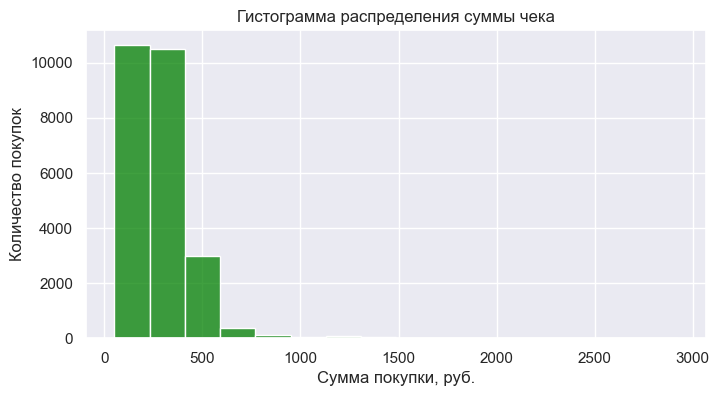

In [97]:
sns.histplot(amount, bins='sturges', color='green')
plt.title('Гистограмма распределения суммы чека')
plt.xlabel('Сумма покупки, руб.')
plt.ylabel('Количество покупок')
plt.show()

In [98]:
# малоинформативно

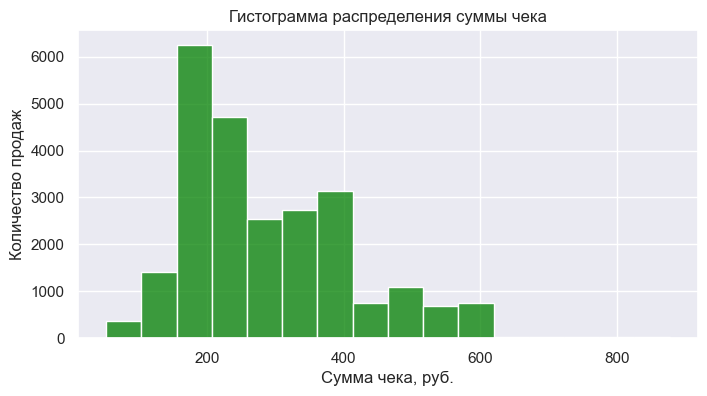

In [99]:
# построим гистограмму, ограничив 99 процентилем
sns.histplot(amount[amount<amount.quantile(0.99)], bins='sturges', color='green')
plt.title('Гистограмма распределения суммы чека')
plt.xlabel('Сумма чека, руб.')
plt.ylabel('Количество продаж')
plt.show()

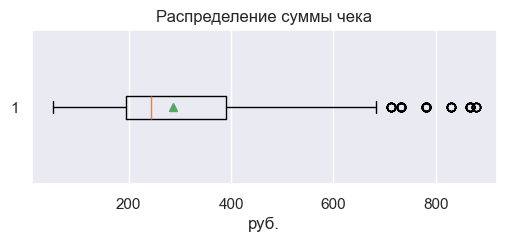

In [100]:
# построим боксплот, ограничив 99 процентилем
plt.figure(figsize=(6, 2))
plt.boxplot(amount[amount < amount.quantile(0.99)], vert=False, showmeans=True)
plt.grid(axis='y')
plt.title('Распределение суммы чека')
plt.xlabel('руб.')
plt.show()

In [101]:
# коэффициент ассиметрии
amount.skew()

np.float64(4.953114045851689)

In [102]:
# коэффициент эксцесса
amount.kurtosis()

np.float64(52.57617469685016)

In [103]:
#  Тест на нормальность распределения.
#  Н0: наблюдаемая выборка принадлежит нормальной генеральной совокупности.
#  Н1: наблюдаемая выборка не принадлежит нормальной генеральной совокупности.
#  Уровень значимости полагаем равным 0,05.

In [104]:
# Необходимо применить тест Д'Агостино-Пирсона для больших выборок наблюдений >5000.
stats.normaltest(amount)

NormaltestResult(statistic=np.float64(25657.986508462018), pvalue=np.float64(0.0))

In [105]:
# Так же подходит тест Колмогорова-Смирнова для больших выборок наблюдений
stats.kstest(amount, 'norm')

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(52.0), statistic_sign=np.int8(-1))

In [106]:
# p-value < уровня значимости 0,05 по обоим тестам, отвергаем гипотезу Н0
# выборка не принадлежит нормальной генеральной совокупности

In [107]:
# Так же можем проверим признак на нормальность при помощи критерия Андерсона для больших выборок наблюдений
stats.anderson(amount, dist = 'norm')

AndersonResult(statistic=np.float64(1095.0313791740336), critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(298.6842461067965), scale=np.float64(177.89763916877868))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [108]:
# Статистика критерия (statistic) значительно превышает самое большое критическое значение (critical_values),
# соответственно на данном уровне значимости гипотеза о нормальности распределения отвергается
# с очень высокой степенью уверенности.

**Выводы**:
1. Минимальная сумма чека по исходной выборке 52 руб., максимальная 23400 руб. Размах составил 23348 руб. В процессе анализа данных было выявлено, что максимальное значение единственное и является экстремальным. Было принято решение исключить его из выборки. После исключения максимальное значение составило 2925 руб., размах составил 2873 руб.
2. Нулевых значениий по признаку нет.
3. Средняя сумма чека ~300 руб., медианное значение 243.75 руб. Смещение среднего вправо от медианы говорит о несимметричном распределении данных.
4. Сумма 10% чеков не превышает 162.5 руб., сумма 25% чеков не превышает 195 руб., сумма 50% чеков не превышает 243.75 руб., сумма 75% чеков не превышает 390 руб., сумма 90% чеков не превышает 487.5 руб.
5. Боксплот показывает наличие длинного "хвоста" справа и немногочисленные выбросы справа, что свидетельствует об отличии распределения признака от нормального. На гистограмме также видно, что распределение признака отлично от нормального. Гистограмма показывает несимметричное распределение, скошенное влево, два пика.
6. Коэффициент ассиметрии больше 0, что так же свидетельствует о скошенности вправо. Коэффициент эксцесса много больше 0, что говорит о большой сосредоточенности значений вокруг среднего, т.е. острой вершине. По проведенным тестам на нормальность распределения p-value меньше уровня значимости 0,05 и статистика критерия Андерона значительно превышает самое большое критическое значение, поэтому гипотеза Н0 о нормальности распределения признака отвергается. Соответственно в дальнейшем при анализе взаимосвязи признаков следует применять непараметрические критерии сравнения групп: для 2х независимых групп - критерий Манна-Уитни и др., для более 2х независимых групп - критерий Краскала-Уоллиса.
7. Целесообразно дополнительно рассмотреть общую сумму прибыли `(profit)` в разрезе остальных признаков.

### quantity

In [109]:
# выведем Series
quantity = df_copy.quantity

In [110]:
min_value = quantity.min()
max_value = quantity.max()
mean_value = quantity.mean()
median_value = quantity.median()
std_value = quantity.std()
print(f'Наименьшее количество товаров в чеке: {min_value}',
      f'Наибольшее количество товаров в чеке: {max_value}',
      f'Среднее количество товаров в чеке: {mean_value}',
      f'Медианное количество товаров в чеке: {median_value}',
      f'Средне квадратическое отклонение: {std_value}', sep='\n')

Наименьшее количество товаров в чеке: 1
Наибольшее количество товаров в чеке: 4
Среднее количество товаров в чеке: 1.4351937547784797
Медианное количество товаров в чеке: 1.0
Средне квадратическое отклонение: 0.5263434298246221


In [111]:
quantity.describe()

count    24851.000000
mean         1.435194
std          0.526343
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: quantity, dtype: float64

In [112]:
percentile_10_value = quantity.quantile(0.10)
percentile_25_value = quantity.quantile(0.25)
percentile_50_value = quantity.quantile(0.50)
percentile_75_value = quantity.quantile(0.75)
percentile_90_value = quantity.quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 1.0
25-й процентиль: 1.0
50-й процентиль: 1.0
75-й процентиль: 2.0
90-й процентиль: 2.0


In [113]:
# количество наблюдений, число товоров в чеке по которым превышает 90 процентиль
(quantity>quantity.quantile(0.90)).sum()

np.int64(378)

In [114]:
# количество наблюдений, число товоров в чеке по которым превышает 99 процентиль
(quantity>quantity.quantile(0.99)).sum()

np.int64(5)

In [115]:
# посмотрим значение 99 процентиля
quantity.quantile(0.99)

np.float64(3.0)

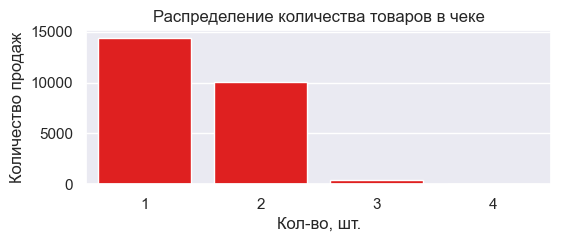

In [116]:
plt.figure(figsize=(6, 2))
sns.countplot(x='quantity', data=df_copy, color='red')
plt.title('Распределение количества товаров в чеке')
plt.xlabel('Кол-во, шт.')
plt.ylabel('Количество продаж')
plt.show()

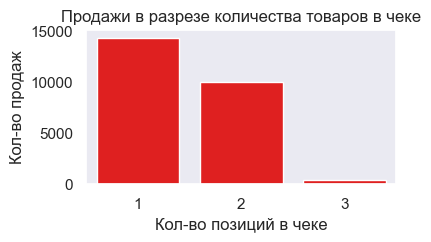

In [117]:
# построим диаграмму до 99 процентиля
plt.figure(figsize=(4, 2))
filtered_df = df_copy[df_copy['quantity'] <= df_copy['quantity'].quantile(0.99)]
ax = sns.countplot(x='quantity', data=filtered_df, color='red')
ax.grid(False)
plt.title('Продажи в разрезе количества товаров в чеке')
plt.xlabel('Кол-во позиций в чеке')
plt.ylabel('Кол-во продаж')
plt.show()

In [118]:
# коэффициент ассиметрии
quantity.skew()

np.float64(0.5896881247384326)

In [119]:
# коэффициент эксцесса
quantity.kurtosis()

np.float64(-0.9061786410385446)

In [120]:
#  Тест на нормальность распределения. Определим гипотезу.
#  Н0: наблюдаемая выборка принадлежит нормальной генеральной совокупности.
#  Н1: наблюдаемая выборка не принадлежит нормальной генеральной совокупности.
#  Уровень значимости полагаем равным 0,05.

In [121]:
# Применим тест Д'Агостино-Пирсона для больших выборок наблюдений >5000.
stats.normaltest(quantity)

NormaltestResult(statistic=np.float64(4763.417377345671), pvalue=np.float64(0.0))

In [122]:
# p-value < уровня значимости 0,05, отвергаем гипотезу Н0
# выборка не принадлежит нормальной генеральной совокупности

**Выводы**:
1. Наименьшее количество товаров в чеке по исходной выборке 1 шт., наибольшее 4 шт. Размах составил 3 шт.
2. Нулевых значениий по признаку нет.
3. Медианное значение 1 шт.
4. Число товаров в 10%, 25% и 50% чеков не превышает 1 шт., число товаров в 75% и 90% чеков не превышает 2 шт.
5. На диаграмме видно, что распределение признака отлично от нормального. Гистограмма показывает несимметричное распределение, скошенное влево.
6. Коэффициент ассиметрии больше 0, что так же свидетельствует о скошенности вправо. Коэффициент эксцесса отрицательный -0,9, что говорит о более "расплющеном" и менее концентрированом около среднего распределении, данные менее склонны к выбросам и экстремальным значениям, такое распределение указывает на более равномерное распределение значений без сильных пиков. По проведенному тесту на нормальность распределения p-value меньше уровня значимости 0,05, поэтому гипотеза Н0 о нормальности распределения признака отвергается. Соответственно в дальнейшем при анализе взаимосвязи признаков следует применять непараметрические критерии сравнения групп: для 2х независимых групп - критерий Манна-Уитни и др., для более 2х независимых групп - критерий Краскала-Уоллиса.


### age

In [123]:
# выведем Series
age = df_copy.age

In [124]:
min_value = age.min()
max_value = age.max()
mean_value = age.mean()
median_value = age.median()
std_value = age.std()
print(f'Наименьший возраст: {min_value}',
      f'Наибольший возраст: {max_value}',
      f'Средний возраст: {mean_value}',
      f'Медианное значение возраста: {median_value}',
      f'Средне квадратическое отклонение: {std_value}', sep='\n')

Наименьший возраст: 24
Наибольший возраст: 75
Средний возраст: 46.74709267232707
Медианное значение возраста: 44.0
Средне квадратическое отклонение: 15.091796214356894


In [125]:
age.describe()

count    24851.000000
mean        46.747093
std         15.091796
min         24.000000
25%         33.000000
50%         44.000000
75%         60.000000
max         75.000000
Name: age, dtype: float64

In [126]:
percentile_10_value = age.quantile(0.10)
percentile_25_value = age.quantile(0.25)
percentile_50_value = age.quantile(0.50)
percentile_75_value = age.quantile(0.75)
percentile_90_value = age.quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 28.0
25-й процентиль: 33.0
50-й процентиль: 44.0
75-й процентиль: 60.0
90-й процентиль: 69.0


In [291]:
# количество наблюдений, значения возраста по которым превышает 90 процентиль
(age > age.quantile(0.90)).sum()

np.int64(2373)

In [290]:
# количество наблюдений, значения возраста по которым превышает 99 процентиль
(age > age.quantile(0.99)).sum()

np.int64(0)

In [289]:
# количество наблюдений, значения возраста по которым превышает 98 процентиль
(age > age.quantile(0.98)).sum()

np.int64(261)

In [130]:
# посмотрим значение 98 процентиля
age.quantile(0.98)

np.float64(74.0)

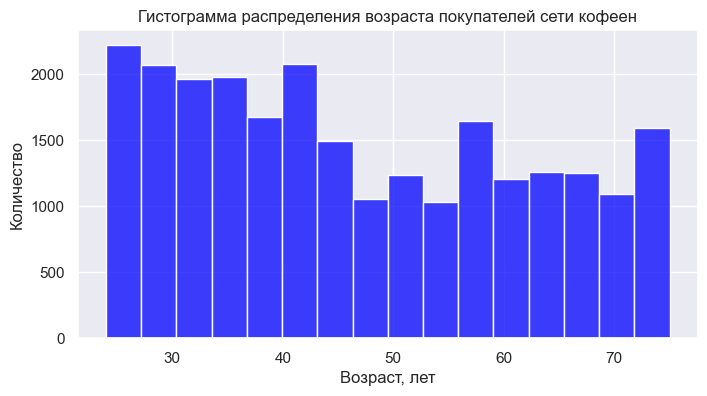

In [131]:
sns.histplot(age, bins='sturges', color='blue')
plt.title('Гистограмма распределения возраста покупателей сети кофеен')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество')
plt.show()

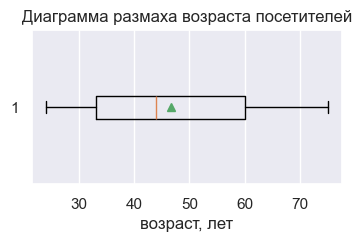

In [132]:
plt.figure(figsize=(4, 2))
plt.boxplot(age, vert=False, showmeans=True)
plt.title('Диаграмма размаха возраста посетителей')
plt.xlabel('возраст, лет')
plt.grid(False, axis='y')
plt.show()

In [133]:
# коэффициент ассиметрии
age.skew()

np.float64(0.2808762203598216)

In [134]:
# коэффициент эксцесса
age.kurtosis()

np.float64(-1.2071572653988536)

In [135]:
#  Тест на нормальность распределения. Определим гипотезу.
#  H0: наблюдаемая выборка принадлежит нормальной генеральной совокупности.
#  H1: наблюдаемая выборка не принадлежит нормальной генеральной совокупности.
#  Уровень значимости полагаем равным 0,05.

In [136]:
# Использую тест Д'Агостино-Пирсона для больших выборок наблюдений
stats.normaltest(age)

NormaltestResult(statistic=np.float64(23734.298503649883), pvalue=np.float64(0.0))

In [137]:
# Так же применим тест Колмогорова-Смирнова для больших выборок наблюдений
stats.kstest(age, 'norm')

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.int64(24), statistic_sign=np.int8(-1))

In [138]:
# p-value < уровня значимости 0,05, отвергаем гипотезу Н0
# выборка не принадлежит нормальной генеральной совокупности

In [139]:
# Дополнительно проверю признак на нормальность при помощи критерия Андерсона для больших выборок наблюдений:
stats.anderson(age, dist = 'norm')

AndersonResult(statistic=np.float64(462.696881706157), critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(46.74709267232707), scale=np.float64(15.091796214356894))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [140]:
# Статистика критерия (statistic) значительно превышает самое большое критическое значение (critical_values),
# соответственно на данном уровне значимости гипотеза о нормальности распределения отвергается
# с очень высокой степенью уверенности.

**Выводы**:
1. Минимальное значение возраста 24 года, максимальное 75 лет. Размах значений составил 51 год.
2. Нулевых значений в данных нет.
3. Среднее значение составило ~47 лет, медианное 44 года. Значения отличаются, небольшое отклонение может быть следствием асимметричного распределения данных.
4. Возраст 10% покупателей не превышает 28 лет, возраст 25% покупателей не превышает 33 лет, возраст 50% покупателей не превышает 44 года, возраст 75% покупателей не превышает 60 лет, возраст 90% покупателей не превышает 69 лет.
5. На графиках выбросы отсутствуют. Боксплот показывает наличие длинного "хвоста" справа, что свидетельствует об отличии распределения признака от нормального. На гистограмме также видно, что распределение признака отлично от нормального. Гистограмма показывает несимметричное распределение, скошенное влево, несколько пиков. Целесообразно разделить возраст на категории (например, 24-34, 35-46, 47-56, свыше 57), которые в дальнейшем проанализировать отдельно.
6. Коэффициент ассиметрии больше 0, что так же свидетельствует о скошенности вправо. Коэффициент эксцесса меньше 0, что говорит о более плоском распределении с тонкими хвостами. По проведенным тестам на нормальность распределения p-value меньше уровня значимости 0,05 и статистика критерия Андерона значительно превышает самое большое критическое значение, поэтому гипотеза Н0 о нормальности распределения признака отвергается. Соответственно в дальнейшем при анализе взаимосвязи признаков следует применять непараметрические критерии сравнения групп: для 2х независимых групп - критерий Манна-Уитни и др., для более 2х независимых групп - критерий Краскала-Уоллиса.

## 4.1.1. Рассмотрим прибыль в разрезе факторных признаков

### profit - outlet_id

In [141]:
grouped = df_copy.groupby('outlet_id')['amount'].sum()
profit_outlet = grouped.sort_values(ascending=False)
profit_outlet

outlet_id
5    2604307.55
3    2515132.10
8    2303162.55
Name: amount, dtype: float64

In [142]:
# сбросим индекс
profit_outlet = profit_outlet.reset_index()
profit_outlet

,outlet_id,amount
0,5,2604307.55
1,3,2515132.10
2,8,2303162.55


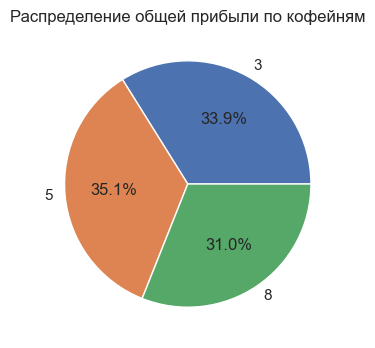

In [293]:
profit_outlet_sorted = profit_outlet.sort_values(by='outlet_id', ascending=True)
plt.pie(profit_outlet_sorted['amount'].values,
        labels=profit_outlet_sorted['outlet_id'].astype(str).values,
        autopct='%.1f%%')
plt.title('Распределение общей прибыли по кофейням')
plt.show()

**Выводы:**
1. Распределение прибыли примерно равное по всем 3-м кофейням.

### profit - city

In [144]:
# оценим прибыль по городам
profit_city = df_copy.groupby('city')['amount'].sum().reset_index()
profit_city

,city,amount
0,москва,4907470.1
1,санкт-петербург,2515132.1


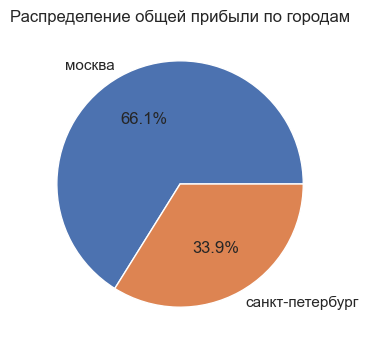

In [145]:
plt.pie(profit_city['amount'], labels = profit_city['city'], autopct='%.1f%%')
plt.title('Распределение общей прибыли по городам')
plt.show()



**Выводы:**
1. Круговая диаграмма показывает в Москве прибыль в 2 раза больше, что обусловлено разницей количества кофеен так же в 2 раза.

### profit - gender

In [146]:
# оценим прибыль в разрезе пола покупателей
profit_gender = df_copy.groupby('gender')['amount'].sum().reset_index()
profit_gender

,gender,amount
0,женский,3246235.2
1,мужской,2454013.9
2,не указан,1722353.1


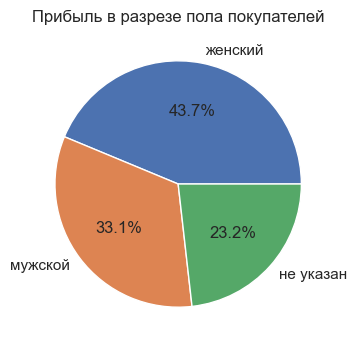

In [147]:
plt.pie(profit_gender['amount'], labels = profit_gender['gender'], autopct='%.1f%%')
plt.title('Прибыль в разрезе пола покупателей')
plt.show()

**Выводы:**
1. Женщины приносят больше прибыли, чем мужчины при рассмотрении наблюдений с указанным полом.


### profit - category

In [148]:
# оценим прибыль по категориям товаров
grouped_profit_cat = df_copy.groupby('category')['amount'].sum()
profit_category = grouped_profit_cat.sort_values(ascending=False)
profit_category

category
coffee                2962352.25
tea                   2190841.25
bakery                 889266.30
drinking chocolate     796363.75
coffee beans           292295.25
branded                 96590.00
loose tea               92985.75
flavours                64116.00
packaged chocolate      37791.65
Name: amount, dtype: float64

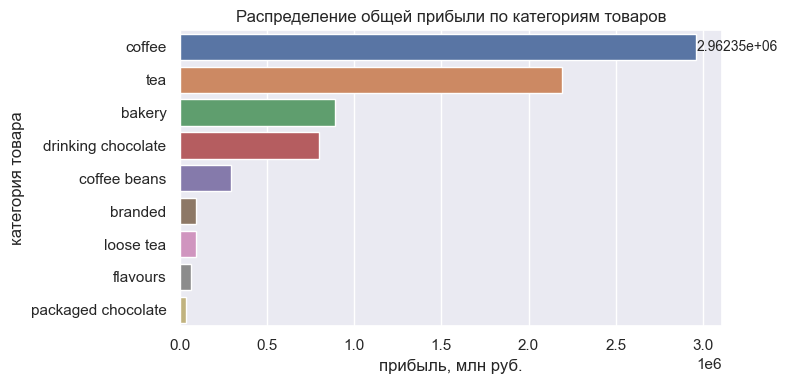

In [149]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(y=profit_category.index, hue=profit_category.index, x=profit_category.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение общей прибыли по категориям товаров')
plt.xlabel('прибыль, млн руб.')
plt.ylabel('категория товара')
plt.tight_layout()
plt.show()

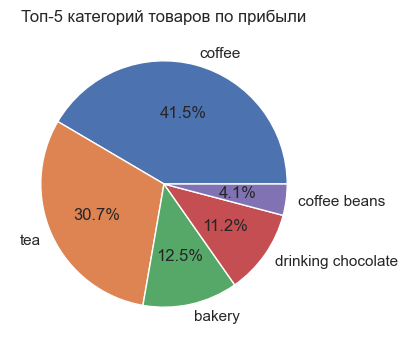

In [150]:
# посмотрим на топ-5 самых прибыльных категорий товаров
category_profit_top = profit_category[:5]

plt.pie(category_profit_top, labels=category_profit_top.index, autopct='%.1f%%')
plt.title('Топ-5 категорий товаров по прибыли')
plt.show()

**Выводы:**
1. Категория coffee приносит больше всего прибыли, категория packaged chocolate - меньше всего.


### profit - product

In [151]:
# оценим прибыль в разрезе товаров
grouped_profit_prod = df_copy.groupby('product')['amount'].sum()
profit_product = grouped_profit_prod.sort_values(ascending=False)
profit_product

product
sustainably grown organic lg    237428.75
dark chocolate lg               225810.00
latte rg                        195861.25
morning sunrise chai lg         194740.00
latte                           194268.75
                                  ...    
guatemalan sustainably grown     11700.00
spicy eye opener chai             9252.75
dark chocolate                    8736.00
earl grey                         8726.25
peppermint                        8144.50
Name: amount, Length: 80, dtype: float64

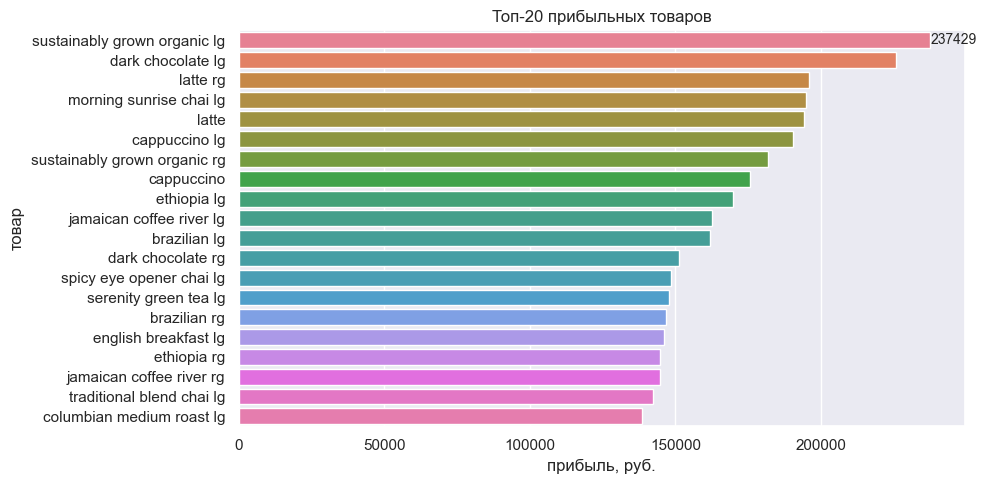

In [152]:
# посмотрим на топ-20 самых прибыльных товаров
product_profit_top = profit_product[:20]

plt.figure(figsize=(10, 5))
ax = sns.barplot(y=product_profit_top.index, hue=product_profit_top.index, x=product_profit_top.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Топ-20 прибыльных товаров')
plt.xlabel('прибыль, руб.')
plt.ylabel('товар')
plt.tight_layout()
plt.show()

In [153]:
# список 20 самых прибыльных товаров
product_profit_top_list = product_profit_top.index
product_profit_top_list

Index(['sustainably grown organic lg', 'dark chocolate lg', 'latte rg',
       'morning sunrise chai lg', 'latte', 'cappuccino lg',
       'sustainably grown organic rg', 'cappuccino', 'ethiopia lg',
       'jamaican coffee river lg', 'brazilian lg', 'dark chocolate rg',
       'spicy eye opener chai lg', 'serenity green tea lg', 'brazilian rg',
       'english breakfast lg', 'ethiopia rg', 'jamaican coffee river rg',
       'traditional blend chai lg', 'columbian medium roast lg'],
      dtype='object', name='product')

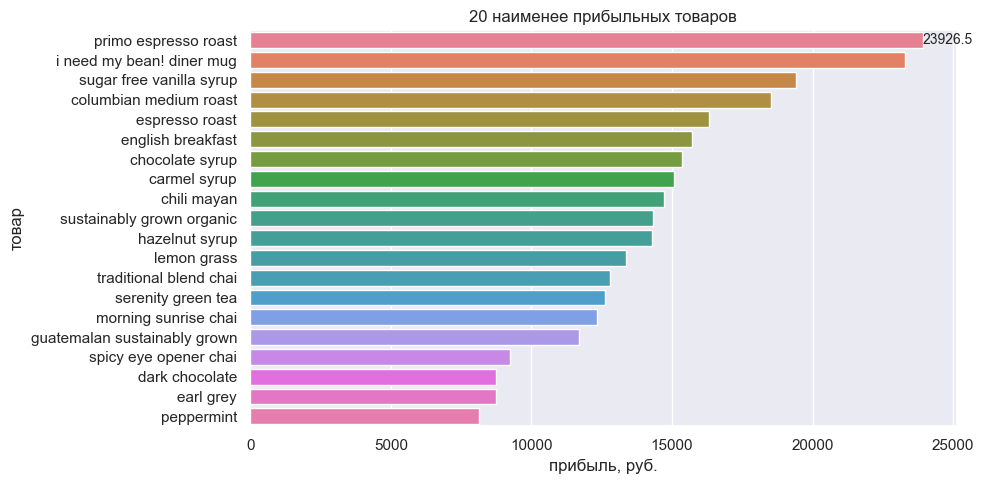

In [154]:
# посмотрим на 20 наименее прибыльных товаров
product_profit_out = profit_product[60:]

plt.figure(figsize=(10, 5))
ax = sns.barplot(y=product_profit_out.index, hue=product_profit_out.index, x=product_profit_out.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('20 наименее прибыльных товаров')
plt.xlabel('прибыль, руб.')
plt.ylabel('товар')
plt.tight_layout()
plt.show()

In [155]:
# список товаров, которые принесли меньше всего прибыли
product_profit_out_list = product_profit_out.index
product_profit_out_list

Index(['primo espresso roast', 'i need my bean! diner mug',
       'sugar free vanilla syrup', 'columbian medium roast', 'espresso roast',
       'english breakfast', 'chocolate syrup', 'carmel syrup', 'chili mayan',
       'sustainably grown organic', 'hazelnut syrup', 'lemon grass',
       'traditional blend chai', 'serenity green tea', 'morning sunrise chai',
       'guatemalan sustainably grown', 'spicy eye opener chai',
       'dark chocolate', 'earl grey', 'peppermint'],
      dtype='object', name='product')

**Выводы:**
1. Выявили 2-х абсолютных лидеров по прибыли: 'sustainably grown organic lg', 'dark chocolate lg'
2. Выявили 20 товаров, принесших наименьшую прибыль. Список: 'primo espresso roast', 'i need my bean! diner mug',
       'sugar free vanilla syrup', 'columbian medium roast', 'espresso roast',
       'english breakfast', 'chocolate syrup', 'carmel syrup', 'chili mayan',
       'sustainably grown organic', 'hazelnut syrup', 'lemon grass',
       'traditional blend chai', 'serenity green tea', 'morning sunrise chai',
       'guatemalan sustainably grown', 'spicy eye opener chai',
       'dark chocolate', 'earl grey', 'peppermint'.
3. Выявили 20 товаров, принесших наибольшую прибыль. Список: 'sustainably grown organic lg', 'dark chocolate lg', 'latte rg',
       'morning sunrise chai lg', 'latte', 'cappuccino lg',
       'sustainably grown organic rg', 'cappuccino', 'ethiopia lg',
       'jamaican coffee river lg', 'brazilian lg', 'dark chocolate rg',
       'spicy eye opener chai lg', 'serenity green tea lg', 'brazilian rg',
       'english breakfast lg', 'ethiopia rg', 'jamaican coffee river rg',
       'traditional blend chai lg', 'columbian medium roast lg'

## 4.2. Категориальные признаки

### product

In [156]:
product = df_copy['product']
product.describe()

count                       24851
unique                         80
top       morning sunrise chai rg
freq                          521
Name: product, dtype: object

In [157]:
product.mode()

0    morning sunrise chai rg
Name: product, dtype: object

In [158]:
product.value_counts()

product
morning sunrise chai rg         521
columbian medium roast rg       516
latte                           516
sustainably grown organic lg    516
traditional blend chai rg       515
                               ... 
espresso roast                   17
chili mayan                      17
earl grey                        15
peppermint                       14
spicy eye opener chai            13
Name: count, Length: 80, dtype: int64

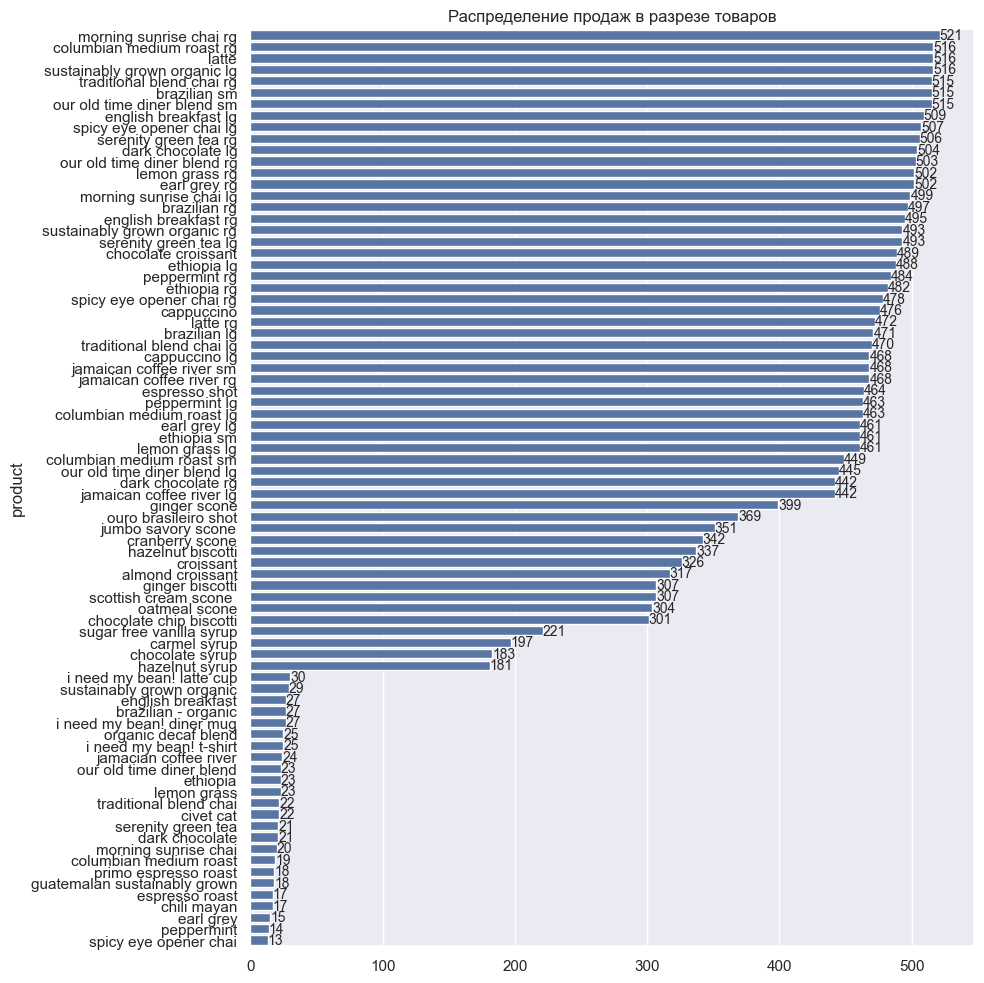

In [159]:
plt.figure(figsize=(10, 10))
ax = sns.barplot(y=product.value_counts().index, x=product.value_counts().values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение продаж в разрезе товаров')
plt.tight_layout()
plt.show()

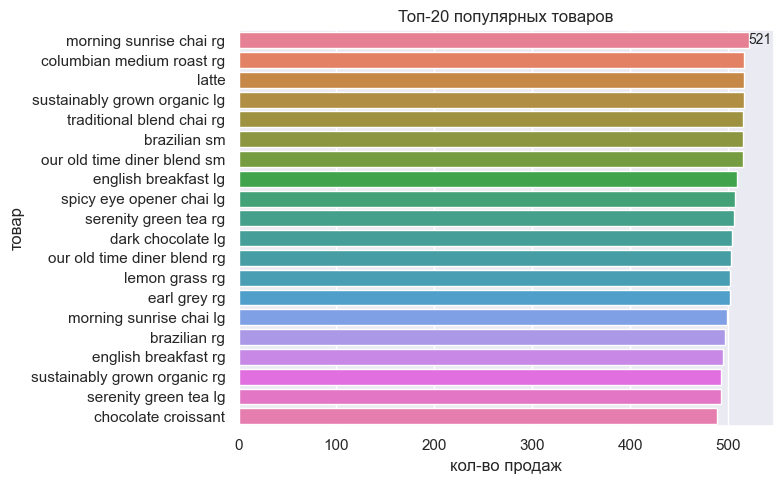

In [160]:
# посмотрим на топ-20 самых популярных продуктов
product_count_top = df_copy['product'].value_counts()[:20]

plt.figure(figsize=(8, 5))
ax = sns.barplot(y=product_count_top.index, hue=product_count_top.index, x=product_count_top.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Топ-20 популярных товаров')
plt.xlabel('кол-во продаж')
plt.ylabel('товар')
plt.tight_layout()
plt.show()

In [161]:
# список 20 самых популятных товаров
product_count_top_list = product_count_top.index
product_count_top_list

Index(['morning sunrise chai rg', 'columbian medium roast rg', 'latte',
       'sustainably grown organic lg', 'traditional blend chai rg',
       'brazilian sm', 'our old time diner blend sm', 'english breakfast lg',
       'spicy eye opener chai lg', 'serenity green tea rg',
       'dark chocolate lg', 'our old time diner blend rg', 'lemon grass rg',
       'earl grey rg', 'morning sunrise chai lg', 'brazilian rg',
       'english breakfast rg', 'sustainably grown organic rg',
       'serenity green tea lg', 'chocolate croissant'],
      dtype='object', name='product')

In [162]:
# посмотрим на наименее популярные товары, которые купили 30 раз и менее
product_counts = df_copy['product'].value_counts()
product_count_outsiders = product_counts[product_counts <= 30]
product_count_outsiders

product
i need my bean! latte cup       30
sustainably grown organic       29
english breakfast               27
brazilian - organic             27
i need my bean! diner mug       27
organic decaf blend             25
i need my bean! t-shirt         25
jamacian coffee river           24
our old time diner blend        23
ethiopia                        23
lemon grass                     23
traditional blend chai          22
civet cat                       22
serenity green tea              21
dark chocolate                  21
morning sunrise chai            20
columbian medium roast          19
primo espresso roast            18
guatemalan sustainably grown    18
espresso roast                  17
chili mayan                     17
earl grey                       15
peppermint                      14
spicy eye opener chai           13
Name: count, dtype: int64

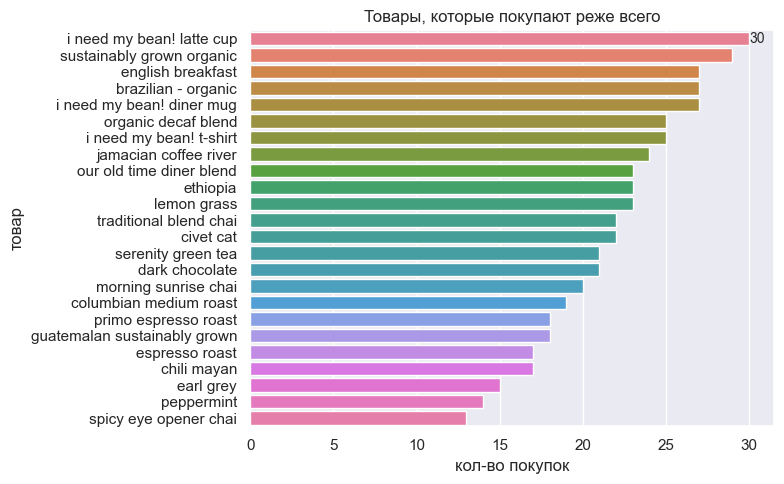

In [163]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(y=product_count_outsiders.index, hue=product_count_outsiders.index,
                 x=product_count_outsiders.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Товары, которые покупают реже всего')
plt.xlabel('кол-во покупок')
plt.ylabel('товар')
plt.tight_layout()
plt.show()

In [164]:
# список товаров, которые покупают реже всего
product_count_outsiders_list = product_count_outsiders.index
product_count_outsiders_list

Index(['i need my bean! latte cup', 'sustainably grown organic',
       'english breakfast', 'brazilian - organic', 'i need my bean! diner mug',
       'organic decaf blend', 'i need my bean! t-shirt',
       'jamacian coffee river', 'our old time diner blend', 'ethiopia',
       'lemon grass', 'traditional blend chai', 'civet cat',
       'serenity green tea', 'dark chocolate', 'morning sunrise chai',
       'columbian medium roast', 'primo espresso roast',
       'guatemalan sustainably grown', 'espresso roast', 'chili mayan',
       'earl grey', 'peppermint', 'spicy eye opener chai'],
      dtype='object', name='product')

In [165]:
# найдем товары, которые покупали реже всего и одновременно наименее прибыльные
common_products = list(set(product_count_outsiders_list) & set(product_profit_out_list))
print(common_products)

['i need my bean! diner mug', 'espresso roast', 'earl grey', 'columbian medium roast', 'serenity green tea', 'peppermint', 'sustainably grown organic', 'english breakfast', 'spicy eye opener chai', 'morning sunrise chai', 'dark chocolate', 'chili mayan', 'traditional blend chai', 'lemon grass', 'primo espresso roast', 'guatemalan sustainably grown']


In [166]:
# Данный список товаров можно предоставить заказчику с рекомендацией вывода из ассортимента

In [167]:
# найдем товары, которые покупали чаще всего и одновременно самые прибыльные
common_products = list(set(product_count_top_list) & set(product_profit_top_list))
print(common_products)

['serenity green tea lg', 'english breakfast lg', 'dark chocolate lg', 'brazilian rg', 'spicy eye opener chai lg', 'sustainably grown organic lg', 'sustainably grown organic rg', 'morning sunrise chai lg', 'latte']


**Выводы**:
1. Количество уникальных позиций, продаваемых в кофейнях - 80.
2. Самый популярный товар - morning sunrise chai rg. Его купили 521 раз.
3. Самый не популярный товар - spicy eye opener chai. Его купили	13 раз.
4. Выявлены аутсайдеры одновременно по продажам и прибыли (всего 16 позиций), можно рекомендовать заказчику вывести эти позиции из оборота.
5. Определили самые популярные и одновременно самые прибыльные товары (всего 9 позиций).

### category

In [168]:
category = df_copy.category
category.describe()

count      24851
unique         9
top       coffee
freq        9948
Name: category, dtype: object

In [169]:
category.mode()

0    coffee
Name: category, dtype: object

In [170]:
category.value_counts()

category
coffee                9948
tea                   7866
bakery                3780
drinking chocolate    1955
flavours               782
coffee beans           216
loose tea              155
branded                 82
packaged chocolate      67
Name: count, dtype: int64

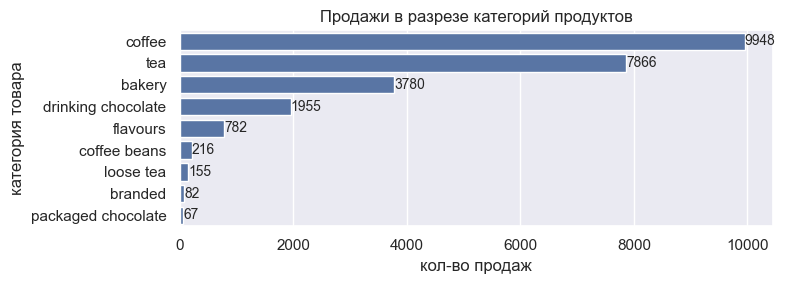

In [171]:
plt.figure(figsize=(8, 3))
ax = sns.barplot(y=category.value_counts().index,
                 x=category.value_counts().values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Продажи в разрезе категорий продуктов')
plt.xlabel('кол-во продаж')
plt.ylabel('категория товара')
plt.tight_layout()
plt.show()

In [172]:
# определим топ-5 популярных категорий продуктов
category_count_top = category.value_counts()[:5]
category_count_top

category
coffee                9948
tea                   7866
bakery                3780
drinking chocolate    1955
flavours               782
Name: count, dtype: int64

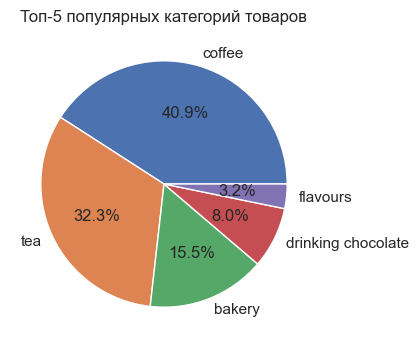

In [173]:
plt.pie(category_count_top, labels=category_count_top.index, autopct='%.1f%%')
plt.title('Топ-5 популярных категорий товаров')
plt.show()

**Вывод**:
1. Количество уникальных категорий товаров - 9.
2. Самая популярная категория - coffee. Товары этой категории купили 9948 раз. В топ-5 категорий товаров доля coffee составила 40.9%.
3. Реже всего покупали товары категорий: coffee beans	(216 раз), loose tea	(155 раз), branded	(82 раз), packaged chocolate (67 раз).


### outlet_id

In [174]:
outlet_id = df_copy.outlet_id
outlet_id.mode()

0    3
Name: outlet_id, dtype: int64

In [175]:
outlet_id.value_counts()

outlet_id
3    8593
5    8545
8    7713
Name: count, dtype: int64

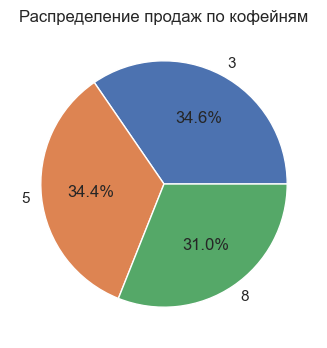

In [176]:
plt.pie(outlet_id.value_counts(), labels = outlet_id.value_counts().index, autopct='%.1f%%')
plt.title('Распределение продаж по кофейням')
plt.show()

In [177]:
# посмотрим распределение продаж по кофейням в Москве
filter = df_copy['city'] == 'москва'
filtered_df = df_copy[filter]
outlet_id_moscow = filtered_df.outlet_id
outlet_id_moscow.value_counts()

outlet_id
5    8545
8    7713
Name: count, dtype: int64

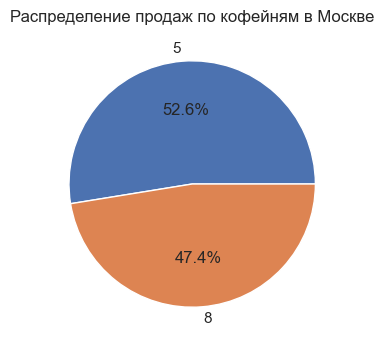

In [178]:
plt.pie(outlet_id_moscow.value_counts(), labels = outlet_id_moscow.value_counts().index, autopct='%.1f%%')
plt.title('Распределение продаж по кофейням в Москве')
plt.show()

**Вывод**:
1. Наибольшее количество продаж было в кофейне с id_3 (8593 продажи)
2. Наименьшее количество продаж было в кофейне с id_8 (7713 продажи)
3. В процентном соотношении количество продаж в трех кофейнях примерно одинаковое.


### city

In [179]:
city = df_copy.city
city.describe()

count      24851
unique         2
top       москва
freq       16258
Name: city, dtype: object

In [180]:
city.mode()

0    москва
Name: city, dtype: object

In [181]:
city.value_counts()

city
москва             16258
санкт-петербург     8593
Name: count, dtype: int64

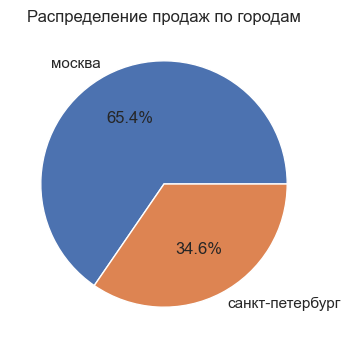

In [182]:
plt.pie(city.value_counts(), labels = city.value_counts().index, autopct='%.1f%%')
plt.title('Распределение продаж по городам')
plt.show()

**Вывод**:
1. Уникальных значений признака - 2.
2. Больше всего покупали в Москве (16258 раз). Меньше в Санкт-Петербурге (8593 раза). Эта разница объясняется 2-мя кофейнями в Москве и одной в Санкт-Петербурге.


### gender

In [183]:
gender = df_copy.gender
gender.describe()

count       24851
unique          3
top       женский
freq        10850
Name: gender, dtype: object

In [184]:
gender.mode()

0    женский
Name: gender, dtype: object

In [185]:
gender.value_counts()

gender
женский      10850
мужской       8222
не указан     5779
Name: count, dtype: int64

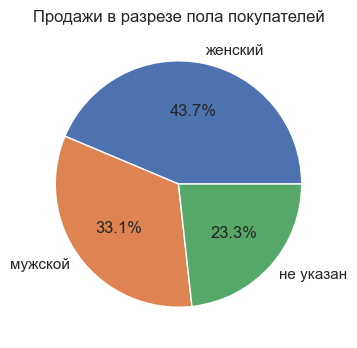

In [186]:
plt.pie(gender.value_counts(), labels = gender.value_counts().index, autopct='%.1f%%')
plt.title('Продажи в разрезе пола покупателей')
plt.show()

**Вывод**:
1. Уникальных значений признака - 3. В 23.3% наблюдений пол не указан.
2. Чаще встречается женский пол - 10850 раз (44%). Реже "не указан" - 5779 раз (23%).
3. Диаграмма показывает преобладание женского пола среди покупателей.


## 4.3. Взаимосвязь количественных признаков

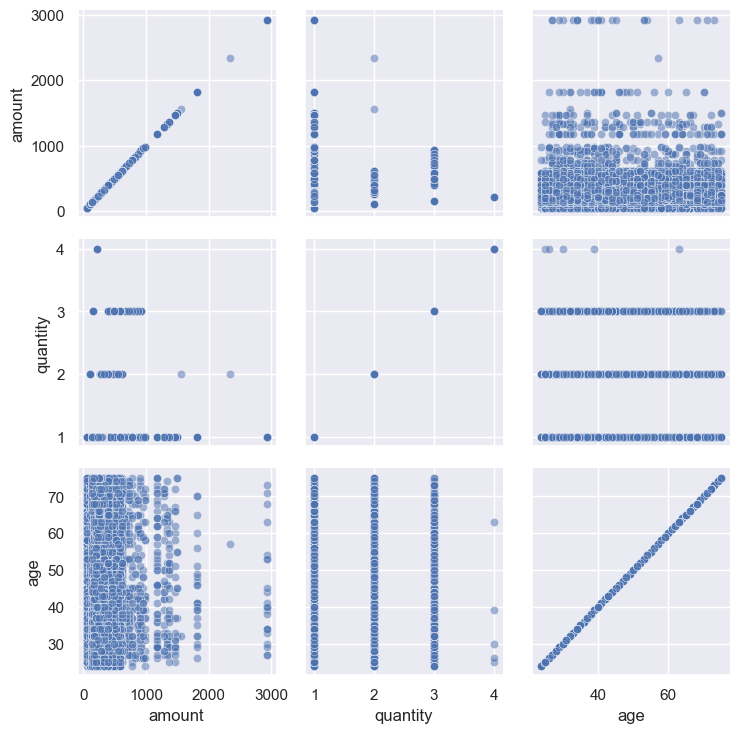

In [187]:
g = sns.PairGrid(df_copy[['amount', 'quantity', 'age']])
g.map(sns.scatterplot, alpha=0.5)
plt.show()

### amount - age

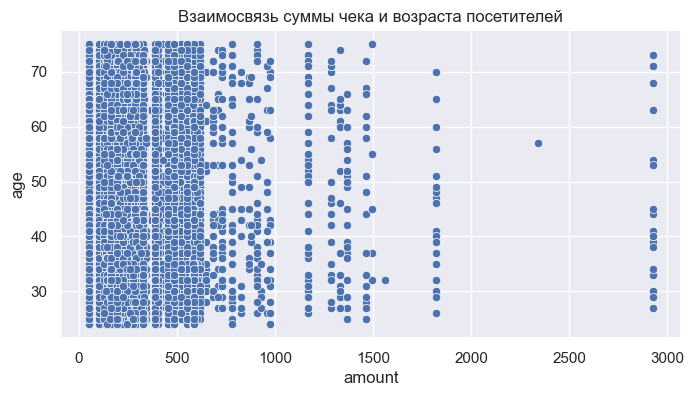

In [188]:
sns.scatterplot(data=df_copy, y='age', x='amount')
plt.title('Взаимосвязь суммы чека и возраста посетителей')
plt.show()

In [189]:
# оценим нелинейную связь используя коэффициент Спирмена, так как данные не являются нормально распределеными
df_copy[['amount', 'age']].corr(method = 'spearman')

,amount,age
amount,1.000000,-0.005936
age,-0.005936,1.000000


In [190]:
# видим почти полное отсутствие нелинейной связи между двумя переменными

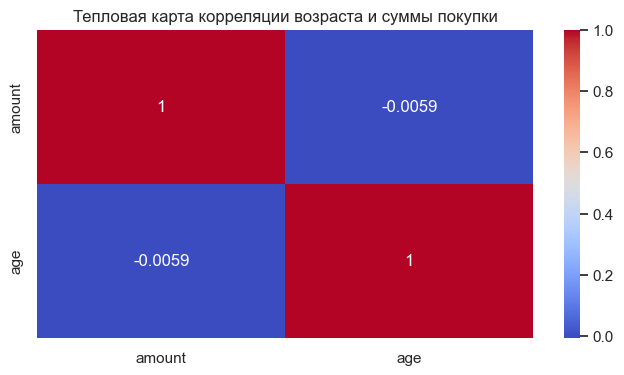

In [191]:
# визуализируем
hm = sns.heatmap(df_copy[['amount', 'age']].corr(method = 'spearman'),annot=True, cmap= 'coolwarm')
hm.set_title('Тепловая карта корреляции возраста и суммы покупки')
plt.show()

In [192]:
# Определим гипотезу.
# Гипотеза Н0: корреляция статистически не значима и связи между признаками нет.
# Гипотеза Н1: корреляция статистически значима и есть связь между признаками.
# Определим уровень значимости =0,05
# Проверим гипотезу о значимости корреляционного коэффициента с помощью теста Спирмена
scipy.stats.spearmanr(df_copy['amount'], df_copy['age'])

SignificanceResult(statistic=np.float64(-0.005936406283726433), pvalue=np.float64(0.349382285266018))

In [193]:
# p-value > уровня значимости 0,05, принимаем H0.
# Следовательно, связь между признаками amount и age статистически НЕ ЗНАЧИМА.

**Выводы:**
1. На общей диаграмме рассеяния нет четко прослеживаемой зависимости суммы чека и возраста посетителей кофеен.
2. Связи между возрастом и суммой чека посетителей кофеен не обнаружено, о чем свидетельствует значение коэффициента кореляции Спирмена, а также результаты теста Спирмена на взаимосвязь признаков (p-value больше уровня значимости 0,05).

## 4.3.1. Рассмотрим прибыль в разрезе возраста

### profit - age

In [194]:
profit_age = df_copy.groupby('age')['amount'].sum().reset_index()

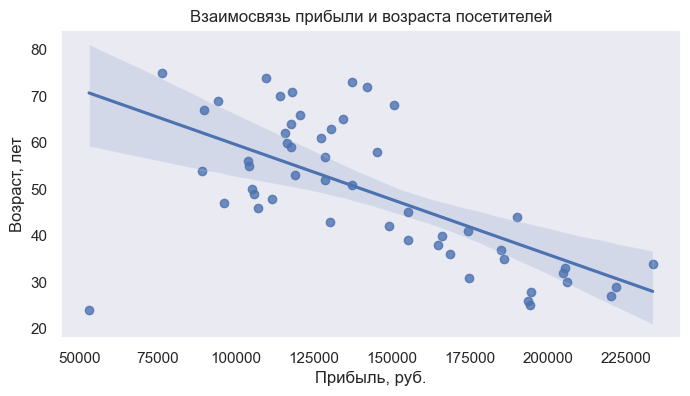

In [195]:
ax = sns.regplot(data=profit_age, y='age', x='amount')
ax.grid(False) # убирает сетку
plt.title('Взаимосвязь прибыли и возраста посетителей')
plt.xlabel("Прибыль, руб.")
plt.ylabel("Возраст, лет")
plt.show()

In [196]:
# На диаграмме рассеяния заметна некоторая связь признаков

In [197]:
# оценим нелинейную связь используя коэффициент Спирмена, так как данные не являются нормально распределеными
profit_age[['amount', 'age']].corr(method = 'spearman')

,amount,age
amount,1.000000,-0.630069
age,-0.630069,1.000000


In [198]:
# по шкале Чеддока сила связи - заметная

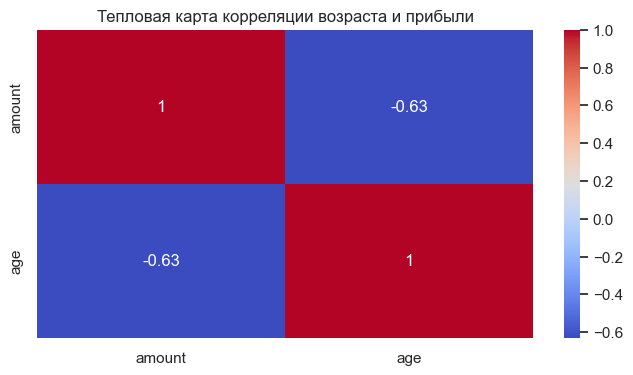

In [199]:
# визуализируем
hm = sns.heatmap(profit_age[['amount', 'age']].corr(method = 'spearman'),annot=True, cmap= 'coolwarm')
hm.set_title('Тепловая карта корреляции возраста и прибыли')
plt.show()

In [200]:
# Определим гипотезу.
# Гипотеза Н0: корреляция статистически не значима и связи между признаками нет.
# Гипотеза Н1: корреляция статистически значима и есть связь между признаками.
# Проверим гипотезу о значимости корреляционного коэффициента с помощью теста Спирмена
scipy.stats.spearmanr(profit_age['amount'], profit_age['age'])

SignificanceResult(statistic=np.float64(-0.6300691539315292), pvalue=np.float64(5.586750838417197e-07))

In [201]:
# p-value < уровня значимости (p=0,05).
# Отвергаем гипотезу H0 в пользу Н1.
# Связь между признаками profit и age статистически значима.

**Выводы:**
1. По общей диаграмме рассеяния заметна связь между прибылью и возрастом посетителей кофеен.
2. Обнаружена заметная обратная монотонная связь между возрастом и прибылью сети кофеен (чем меньше возраст посетителей, тем больше прибыль, которую они принесли), о чем свидетельствует значение коэффициента кореляции Спирмена, а также результаты теста Спирмена на взаимосвязь признаков (p-value меньше уровня значимости 0,05).

## 4.4. Взаимосвязь количественных и категориальных признаков

### age - product

In [202]:
df_copy.groupby('product')['age'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
morning sunrise chai rg,521.0,46.163148,14.504981,24.0,34.00,43.0,59.00,75.0
columbian medium roast rg,516.0,47.757752,14.912347,24.0,34.00,45.0,60.25,75.0
latte,516.0,46.936047,15.182699,24.0,34.00,43.5,62.00,75.0
sustainably grown organic lg,516.0,46.063953,14.191129,24.0,33.00,44.0,58.00,75.0
traditional blend chai rg,515.0,47.497087,15.214085,24.0,34.00,45.0,61.00,75.0
...,...,...,...,...,...,...,...,...
chili mayan,17.0,53.058824,11.855751,34.0,45.00,53.0,61.00,69.0
espresso roast,17.0,44.705882,13.949752,26.0,39.00,41.0,50.00,71.0
earl grey,15.0,45.933333,16.938826,24.0,31.50,41.0,61.50,73.0


In [203]:
# топ-20 товаров
prod_top = df_copy['product'].value_counts()[:20].index
df_top_20 = df_copy[df_copy['product'].isin(prod_top)]

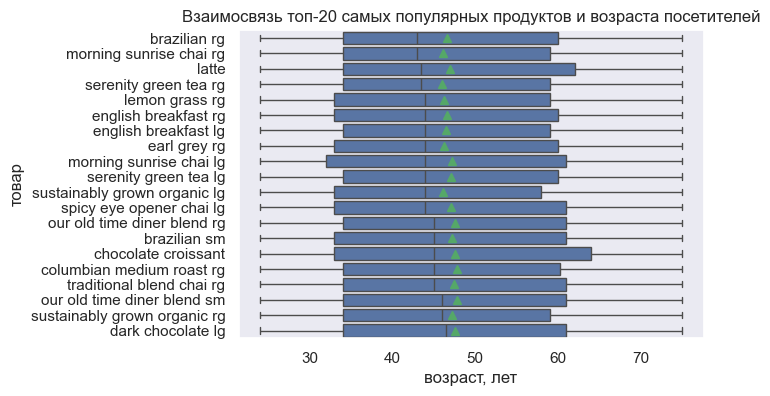

In [204]:
plt.figure(figsize=(6, 4))
ax = sns.boxplot(y='product', x='age', data=df_top_20,
            order=df_top_20.groupby('product')['age'].describe().sort_values(by='50%').index, showmeans=True)
ax.grid(False)
plt.title('Взаимосвязь топ-20 самых популярных продуктов и возраста посетителей')
plt.xlabel("возраст, лет")
plt.ylabel("товар")
plt.show()

In [205]:
# Проверим гипотезу о нормальности данных по группам
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
# если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот
# если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии
for product in df_copy['product'].unique():
    print(product, stats.normaltest(df_copy[df_copy['product']==product]['age'])[1])

traditional blend chai rg 1.484377312243008e-159
brazilian lg 1.4148908230213647e-59
serenity green tea rg 2.6977917762077722e-40
our old time diner blend rg 8.425382485003375e-89
jamaican coffee river sm 1.335192414881572e-39
ethiopia rg 4.325777527450406e-130
english breakfast lg 2.7094710163268405e-55
sustainably grown organic rg 7.59535527644541e-46
earl grey lg 4.774461403868465e-38
jamaican coffee river rg 3.7110835633146674e-53
serenity green tea lg 3.292073501543095e-91
brazilian sm 1.769065845566539e-167
english breakfast rg 5.5448103693663064e-71
traditional blend chai lg 1.6120707797271292e-53
cappuccino 3.574470826147603e-184
espresso shot 1.6182407017842005e-77
cappuccino lg 1.1867675484778575e-75
latte 1.825811421361046e-144
earl grey rg 6.727536206077827e-81
dark chocolate lg 1.8032447712511005e-149
columbian medium roast sm 6.866572054502776e-130
oatmeal scone 2.217074493264071e-15
morning sunrise chai lg 1.921964084272368e-157
morning sunrise chai rg 2.346336826715822e

In [206]:
# так как p-value в части выборок < 0,05  - отвергаем Н0 - распределение данных не подчиняется закону
# о нормальном распределении,попадаем в непараметрический критерий

In [207]:
# Определяем гипотезу связи выбора товара с возрастом покупателя
# H0 - статистически значимые отличия в группах отсутствуют
# H1 - различия статистически значимы
# Проверим гипотезу с помощью критерия Краскала-Уоллиса.
data_array = list()
for product in df_copy['product'].unique():
    data_array.append(df_copy[df_copy['product']==product]['age'].to_list())

stats.mstats.kruskalwallis(*data_array)

KruskalResult(statistic=np.float64(103.84948747021359), pvalue=np.float64(0.03195939080009053))

In [208]:
# так как p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0
# Следовательно, выбор товара зависит от возраста посетителей.

**Выводы:**
1. По боксплотам взаимосвязь между признаками прослеживается. Для визуализации были выбраны топ-20 продуктов по популярности. Распределения признаков имеют небольшие различия, крайние распределения совпадают.
2. Распределения не являются нормальными, о чем свидетельствуют проведенные тесты.
3. Медианные и средние значения возраста покупателей в зависимости от продуктов, которые они покупают отличаются и расположены в промежутках 43 - 47  и 47 - 48 лет соответственно.
4. Взаимосвязь возраста и продуктов является статистически значимой, т.е. одни продукты покупают более молодые посетители, другие - более зрелые.


### age - category

In [209]:
df_copy.groupby('category')['age'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
coffee,9948.0,47.001910,15.129244,24.0,34.00,44.0,60.0,75.0
tea,7866.0,46.379990,15.013803,24.0,33.00,44.0,59.0,75.0
bakery,3780.0,46.748942,15.228668,24.0,34.00,44.0,60.0,75.0
drinking chocolate,1955.0,46.939642,14.781120,24.0,33.50,45.0,59.5,75.0
flavours,782.0,46.913043,15.451220,24.0,33.00,45.0,61.0,75.0
coffee beans,216.0,46.745370,15.053856,24.0,33.00,44.5,61.0,75.0
loose tea,155.0,46.335484,16.047121,24.0,32.50,42.0,62.0,75.0
branded,82.0,45.536585,14.594262,24.0,34.25,42.0,55.0,75.0
packaged chocolate,67.0,46.791045,13.957226,25.0,34.50,45.0,59.5,74.0


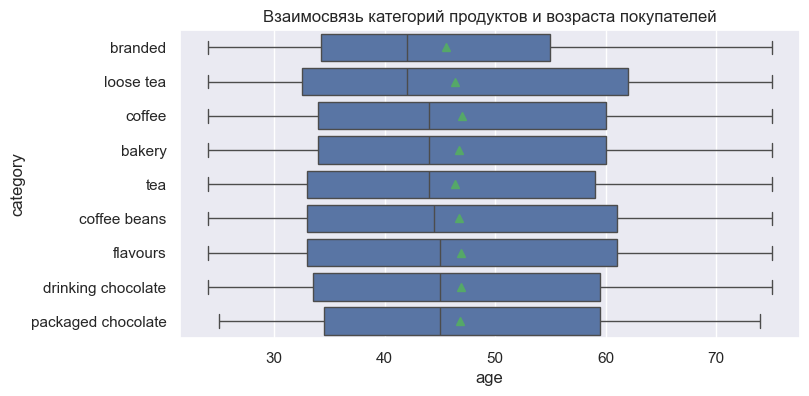

In [210]:
sns.boxplot(y='category', x='age', data=df_copy,
            order=df_copy.groupby('category')['age'].describe().sort_values(by='50%').index, showmeans=True)
plt.title('Взаимосвязь категорий продуктов и возраста покупателей')
plt.show()

In [211]:
# Проверим гипотезу о нормальности данных по группам
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
# если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот
# если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии
for category in df_copy['category'].unique():
    print(category, stats.normaltest(df_copy[df_copy['category']==category]['age'])[1])

tea 0.0
coffee 0.0
drinking chocolate 0.0
bakery 0.0
flavours 2.1742200604220346e-232
coffee beans 2.5914182750312747e-32
loose tea 1.6269089998999309e-24
packaged chocolate 1.9255476286297238e-05
branded 0.019545248147713003


In [212]:
# так как p-value < 0,05 по всем выборкам - отвергаем Н0 - распределение данных не подчиняется закону
# о нормальном распределении,попадаем в непараметрический критерий

In [213]:
# Определяем гипотезу связи выбора категории товара с возрастом покупателя
# H0 - статистически значимые отличия в группах отсутствуют
# H1 - различия статистически значимы
# Проверим гипотезу с помощью критерия Краскала-Уоллиса.
data_array = list()
for category in df_copy.category.unique():
    data_array.append(df_copy[df_copy.category==category]['age'].to_list())

stats.mstats.kruskalwallis(*data_array)

KruskalResult(statistic=np.float64(8.641333452753043), pvalue=np.float64(0.3734496930735215))

In [214]:
# так как p-value > a (=0.05) уровня значимости, то принимаем гипотезу H0
# Следовательно, возраст не влияет на выбор категории продукта

**Выводы:**
1. По боксплотам взаимосвязь между признаками прослеживается. Распределения признаков немного различаются, крайние распределения практически совпадают.
2. Распределения не являются нормальными, о чем свидетельствуют проведенные тесты.
3. Медианные и средние значения возраста покупателей в зависимости от категорий продуктов, которые они выбирают отличаются незначительно и расположены в промежутке между 43 - 45 и 46 - 47 годами соответственно.
4. Взаимосвязь возраста и категории товаров является статистически не значимой, т.е. возраст не влияет на выбор категории товара.


### age - gender

In [215]:
# выберем покупателей, указавших пол
gender = ['женский', 'мужской']
df_copy_gen = df_copy[df_copy.gender.isin(gender)]
df_copy_gen.groupby('gender')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
женский,10850.0,49.255115,14.885540,24.0,36.0,49.0,62.0,75.0
мужской,8222.0,50.754683,14.755767,24.0,38.0,51.0,64.0,75.0


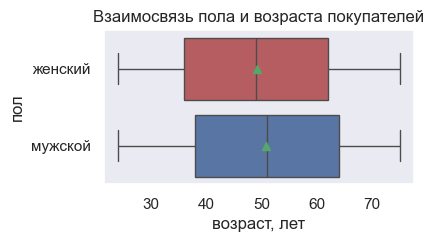

In [216]:
plt.figure(figsize=(4, 2))
ax = sns.boxplot(y='gender', x='age', hue='gender', data=df_copy_gen, palette=['r', 'b'],
            order=df_copy_gen.groupby('gender')['age'].describe().sort_values(by='50%').index, showmeans=True)
ax.grid(False) # убирает сетку
plt.title('Взаимосвязь пола и возраста покупателей')
plt.xlabel("возраст, лет")
plt.ylabel("пол")
plt.show()

In [217]:
# Проверим гипотезу о нормальности данных по группам
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
# если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот
# если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии
for gender in df_copy_gen.gender.unique():
    print(gender, stats.normaltest(df_copy_gen[df_copy_gen.gender==gender]['age'])[1])

женский 0.0
мужской 0.0


In [218]:
# так как p-value < 0,05 по всем выборкам - отвергаем Н0 - распределение данных не подчиняется закону
# о нормальном распределении,попадаем в непараметрический критерий

In [219]:
# Определяем гипотезу связи выбора товара с возрастом покупателя
# H0 - статистически значимые отличия в группах отсутствуют
# H1 - различия статистически значимы
# Проверим гипотезу с помощью критерия Манна-Уитни.
data_array = list()
for gender in df_copy_gen.gender.unique():
    data_array.append(df_copy_gen[df_copy_gen.gender==gender]['age'].to_list())

scipy.stats.mannwhitneyu(*data_array)

MannwhitneyuResult(statistic=np.float64(41998198.0), pvalue=np.float64(4.436634424017184e-12))

In [220]:
# так как p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0
# Следовательно, возраст посетителей кофеен отличается в зависимости от половой принадлежности

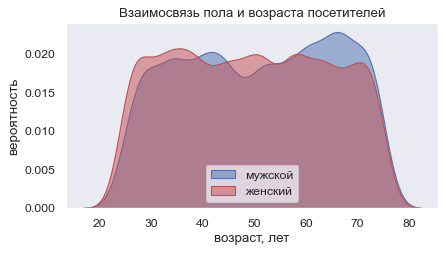

In [221]:
# построим графики плотности распределения возраста в зависимости от пола
plt.figure(figsize=(6,3), dpi= 80)
ax = sns.kdeplot(df_copy.loc[df_copy['gender'] == 'мужской', "age"], fill=True, color="b", label='мужской', alpha=.5)
ax = sns.kdeplot(df_copy.loc[df_copy['gender'] == 'женский', "age"], fill=True, color="r", label='женский', alpha=.5)
ax.grid(False)
plt.title('Взаимосвязь пола и возраста посетителей')
plt.xlabel('возраст, лет')
plt.ylabel('вероятность')
plt.legend()
plt.show()

**Выводы:**
1. По боксплотам взаимосвязь между признаками прослеживается. Распределения признаков похожи, крайние распределения практически совпадают, отличаются Q1 и Q3.
2. На графиках плотностей также заметно различие в распределении возраста в зависимости от пола. Распределения не являются нормальными, о чем свидетельствуют проведенные тесты.
3. Медианные и средние значения возраста покупателей в зависимости от пола, незначительно отличаются и расположены в промежутке между 49(ж) - 51(м)  и 50(ж) - 51(м) годами соответственно.
4. Взаимосвязь возраста и пола является статистически значимой, т.е. возраст посетителей различается в зависимости от пола.
5. Рекомендуется рассмотреть возраст, объединив значения в категории.

### age - city - gender

In [222]:
# распределение возрастов по городам
df_copy.groupby('city')['age'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
москва,16258.0,45.092693,14.920081,24.0,32.0,42.0,58.0,75.0
санкт-петербург,8593.0,49.877226,14.918507,24.0,37.0,50.0,63.0,75.0


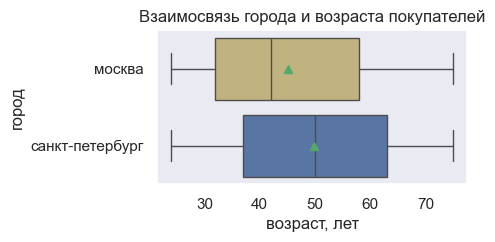

In [223]:
plt.figure(figsize=(4, 2))
ax = sns.boxplot(y='city', x='age', hue='city', data=df_copy, palette=['b', 'y'],
            order=df_copy.groupby('city')['age'].describe().sort_values(by='50%').index, showmeans=True)
ax.grid(False)
plt.title('Взаимосвязь города и возраста покупателей')
plt.xlabel('возраст, лет')
plt.ylabel('город')
plt.show()

In [224]:
# распределение возрастов по полу (пол указан) и городу
df_copy_gen.groupby(['city', 'gender'])['age'].describe()

count       mean        std   min   25%   50%   75%  \
city            gender                                                          
москва          женский  6554.0  49.177296  14.792414  24.0  36.0  49.0  62.0   
                мужской  4996.0  50.953963  14.736480  24.0  38.0  52.0  65.0   
санкт-петербург женский  4296.0  49.373836  15.027453  24.0  36.0  49.0  62.0   
                мужской  3226.0  50.446063  14.782570  24.0  38.0  51.0  64.0   

                          max  
city            gender         
москва          женский  75.0  
                мужской  75.0  
санкт-петербург женский  75.0  
                мужской  75.0

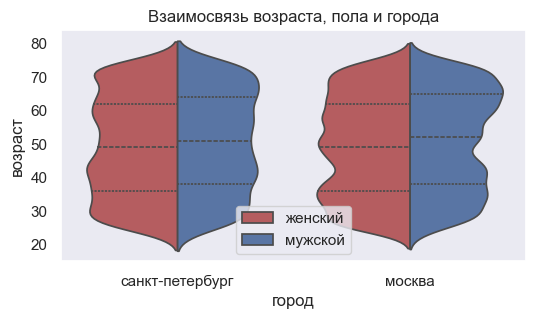

In [225]:
# скрипичная диаграмма
plt.figure(figsize=(6, 3))
ax = sns.violinplot(data=df_copy_gen, x='city', y='age', hue='gender', split=True, inner="quart", palette=['r', 'b'])
ax.grid(False)
plt.title('Взаимосвязь возраста, пола и города')
plt.xlabel('город')
plt.ylabel('возраст')
plt.legend(loc='best')
plt.show()

In [226]:
# Проверим гипотезу о нормальности данных по группам
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
# если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот
# если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии
for city in df_copy.city.unique():
    print(city, stats.normaltest(df_copy[df_copy.city == city]['age'])[1])

санкт-петербург 0.0
москва 0.0


In [227]:
# так как p-value < 0,05 по всем выборкам - отвергаем Н0 - распределение данных не подчиняется закону
# о нормальном распределении,попадаем в непараметрический критерий

In [228]:
# Определяем гипотезу связи города с возрастом покупателя
# H0 - статистически значимые отличия в группах отсутствуют
# H1 - различия статистически значимы
# Проверим гипотезу с помощью критерия Манна-Уитни.
data_array = list()
for city in df_copy.city.unique():
    data_array.append(df_copy[df_copy.city == city]['age'].to_list())

scipy.stats.mannwhitneyu(*data_array)

MannwhitneyuResult(statistic=np.float64(82813055.0), pvalue=np.float64(2.461233927058905e-128))

In [229]:
# так как p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0
# Следовательно, возраст посетителей кофеен отличается в зависимости от города

**Выводы:**
1. По боксплотам взаимосвязь между признаками прослеживается, распределения различаются, медианы разные. По скрипичным диаграммам - не явная связь.
2. Распределения признака не являются нормальным, о чем свидетельствуют проведенные тесты.
3. Медианные и средние значения возраста в Москве и СПб различаются и составляют 42 года и 50 лет (медианные), 45 и 50 лет(средние).
4. Медианные и средние значения по полу приблизительно равны: женский 49 лет, мужской 51 год.
5. В Москве: женский пол - медианное и среднее значение возраста - 49 лет, мужской пол - медианное -52 года, среднее - 51 год.
6. В СПб: женский пол - медианное и среднее значение возраста - 49 лет, мужской пол - медианное -51 года, среднее - 50 год.
7. Взаимосвязь возраста и города проживания посетителей является статистически значимой.

## 4.5. Взаимосвязь категориальных признаков

### age_category - gender

In [230]:
# выделим 4 категории возраста и запишем в отдельный столбец датафрейма
def age_to_category(age):
    '''Функция, которая переводит количественное значение возраста в категориальное по указанным критериям.
       Возвращает категорию'''
    if age < 35:
        age_category = '24-34'
    elif age < 47:
        age_category = '35-46'
    elif age < 57:
        age_category = '47-56'
    else:
        age_category = '57 и старше'
    return age_category

In [231]:
# применим к новому столбцу
df_copy['age_category'] = df_copy['age'].apply(age_to_category)
df_copy.head(1)

,amount,quantity,product_id,product,category,outlet_id,city,customer_id,age,gender,age_category
0,162.5,1,52,traditional blend chai rg,tea,3,санкт-петербург,558,42,женский,35-46


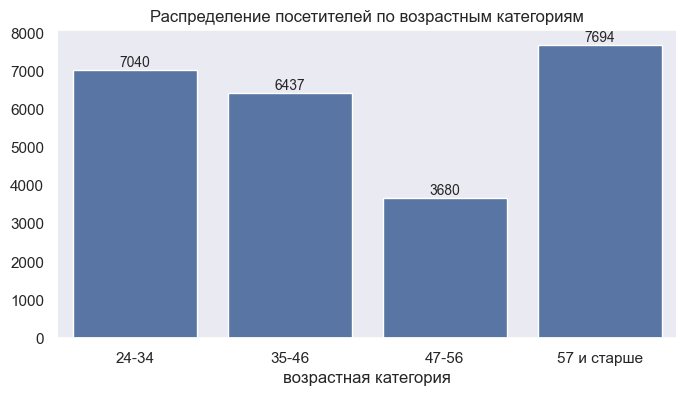

In [232]:
# выведем series
age_category = df_copy.age_category

# визуализируем возраст как категориальный признак
ax = sns.barplot(x=age_category.value_counts().index, y=age_category.value_counts().values,
                order=sorted(df_copy.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.grid(False)
plt.title('Распределение посетителей по возрастным категориям')
plt.xlabel('возрастная категория')
plt.show()

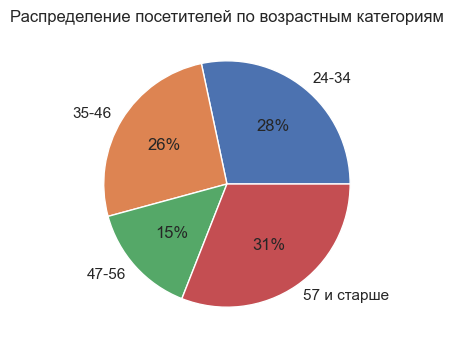

In [233]:
# посмотрим на круговую диаграмму, отсортируем категории по порядку
data_for_pie = age_category.value_counts().sort_index()
ax = plt.pie(x=data_for_pie, labels=data_for_pie.index, autopct='%.0f%%')
plt.title('Распределение посетителей по возрастным категориям')
plt.show()

In [234]:
# дополнительно добавим расчет модального значения возраста
df_copy.groupby('age_category')['age'].describe().join(
df_copy.groupby('age_category')['age'].agg([pd.Series.mode]))

,count,mean,std,min,25%,50%,75%,max,mode
age_category,,,,,,,,,
24-34,7040.0,29.429119,2.999518,24.0,27.0,29.0,32.0,34.0,34
35-46,6437.0,40.195743,3.404229,35.0,37.0,40.0,43.0,46.0,44
47-56,3680.0,51.482609,2.784987,47.0,49.0,51.0,54.0,56.0,51
57 и старше,7694.0,65.809072,5.438936,57.0,61.0,66.0,71.0,75.0,68


In [235]:
gender = ['женский', 'мужской']
df_copy_gen = df_copy[df_copy.gender.isin(gender)]

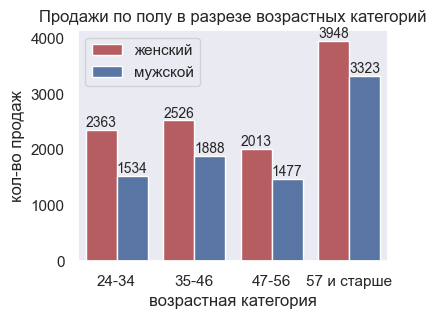

In [236]:
# визуализируем связь пола и возрастных категорий с учетом сортировки по наименованию категорий
plt.figure(figsize=(4, 3))
ax = sns.countplot(data=df_copy_gen, x='age_category', hue='gender', palette=['r', 'b'],
                  order=sorted(df_copy_gen.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.grid(False)
plt.title('Продажи по полу в разрезе возрастных категорий')
plt.xlabel('возрастная категория')
plt.ylabel('кол-во продаж')
plt.legend(loc='upper left')
plt.show()

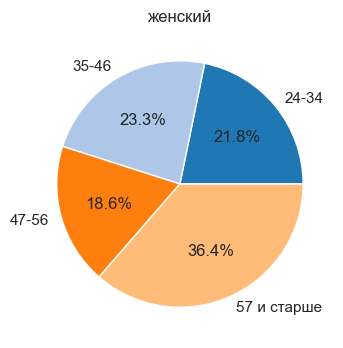

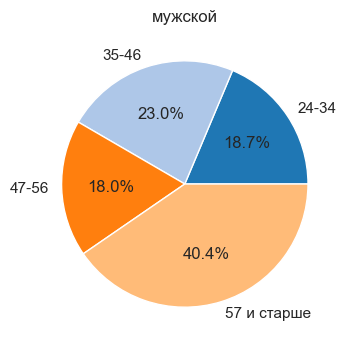

In [237]:
# Дополнительный анализ для сравнения доли каждой возрастной группы по полу

labels = df_copy['age_category'].unique()
colors = plt.cm.tab20.colors[:len(labels)]
colors_list = dict(zip(labels, colors))

gen_count = df_copy_gen['gender'].value_counts().index

for gender in gen_count:
  df = df_copy_gen[df_copy_gen['gender'] == gender]

  age_category_counts = df['age_category'].value_counts().sort_index()
  labels = age_category_counts.index
  values = age_category_counts.values

  plt.title(gender)
  plt.pie(values, labels=labels, colors=colors, autopct='%.1f%%')
  plt.show()

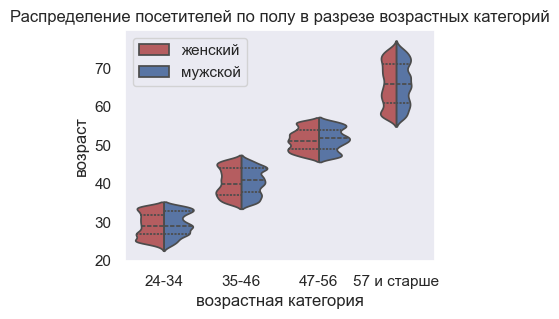

In [238]:
# скрипичная диаграмма
plt.figure(figsize=(4, 3))
ax = sns.violinplot(data=df_copy_gen, x='age_category', y='age',
               hue='gender', split=True, inner="quart", palette=['r', 'b'],
               order=sorted(df_copy_gen.age_category.unique()))
ax.grid(False)
plt.title('Распределение посетителей по полу в разрезе возрастных категорий')
plt.xlabel('возрастная категория')
plt.ylabel('возраст')
plt.legend(loc='upper left')
plt.show()

In [239]:
# таблица сопряженности
WF = pd.crosstab(df_copy_gen.age_category, df_copy_gen.gender); WF

gender,женский,мужской
age_category,,
24-34,2363,1534
35-46,2526,1888
47-56,2013,1477
57 и старше,3948,3323


In [240]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [241]:
# Проверим связь возрастной категории и пола покупателей с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format(chi2, f, prob))

test Statistics: 43.31207273646782
degrees of freedom: 3
p-value: 2.1127510206995e-09



In [242]:
# полученное значение p-value < 0.05, отклоняем гипотезу Н0.
# Данное отличие является статистически значимым.
# Соответственно, в каждой возрастной категории распределение по полу различно.

**Выводы:**
1. После разделения посетителей на 4 группы по возрасту (24-34, 35-46, 47-56, 57 и выше), стало очевидно, что больше всего посетителей в категории 57 лет и старше (31%), далее в категории 24-34 года (28%), 35-46 лет (26%), 47-56 лет (15%).
2. Медианные и средние значения возраста по категориям равны, однако модальные значения отличаются в большую сторону в 3х категориях: категория 24-34 (29 и 34), категория 35-46 (40 и 44), категория 57 и выше (66 и 68).
3. Количество женщин больше, чем мужчин. По столбчатым и скрипичным диаграммам взаимосвязь между признаками очевидна, т.к. распределения отличаются.
4. Взаимосвязь пола и возраста пользователей является статистически значимой, т.е. в каждой возрастной категории распределение по полу различно.

### age_category - city

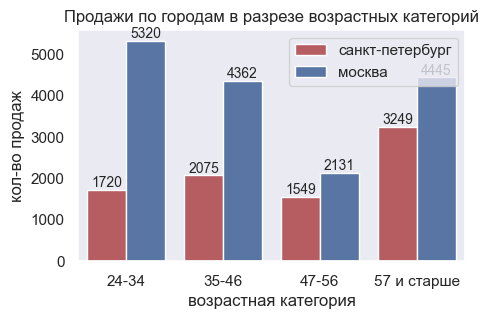

In [243]:
# распределение возрастных групп по городам
plt.figure(figsize=(5, 3))
ax = sns.countplot(data=df_copy, x='age_category', hue='city', palette=['r', 'b'],
                  order=sorted(df_copy.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.grid(False)
plt.title('Продажи по городам в разрезе возрастных категорий')
plt.legend(loc='upper right')
plt.xlabel('возрастная категория')
plt.ylabel('кол-во продаж')
plt.show()

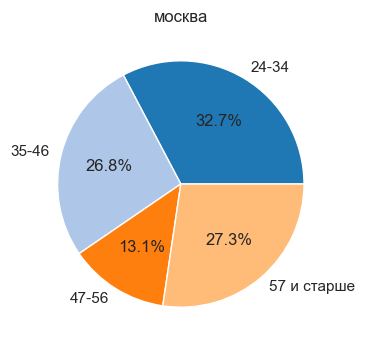

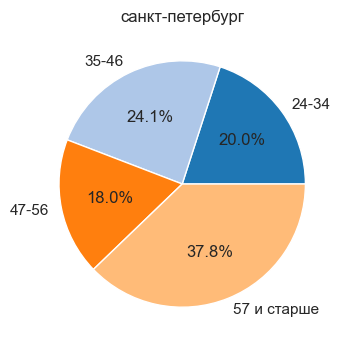

In [244]:
# Дополнительный анализ для сравнения доли каждой возрастной группы в каждом городе,
# так как неравное количество точек продаж может искажать прямые сравнения.

labels = df_copy['age_category'].unique()
colors = plt.cm.tab20.colors[:len(labels)]
colors_list = dict(zip(labels, colors))

city_count = df_copy['city'].value_counts().index

for city in city_count:
  df = df_copy[df_copy['city'] == city]

  age_category_counts = df['age_category'].value_counts().sort_index()
  labels = age_category_counts.index
  values = age_category_counts.values

  plt.title(city)
  plt.pie(values, labels=labels, colors=colors, autopct='%.1f%%')
  plt.show()

In [245]:
# добавим к рассмотрению модальные значения
df_copy.groupby(['city', 'age_category'])['age'].describe().join(
df_copy.groupby(['city', 'age_category'])['age'].agg([pd.Series.mode]))

count       mean       std   min   25%   50%  \
city            age_category                                                  
москва          24-34         5320.0  29.497368  3.003287  24.0  27.0  29.0   
                35-46         4362.0  40.007565  3.394992  35.0  37.0  40.0   
                47-56         2131.0  51.503519  2.735673  47.0  49.0  51.0   
                57 и старше   4445.0  65.674691  5.356541  57.0  61.0  66.0   
санкт-петербург 24-34         1720.0  29.218023  2.978812  24.0  27.0  29.0   
                35-46         2075.0  40.591325  3.390486  35.0  38.0  41.0   
                47-56         1549.0  51.453841  2.852075  47.0  49.0  51.0   
                57 и старше   3249.0  65.992921  5.545236  57.0  61.0  66.0   

                               75%   max      mode  
city            age_category                        
москва          24-34         32.0  34.0        34  
                35-46         43.0  46.0        35  
                47-56         54.0  56.0        51  
                57 и старше   70.0  75.0        68  
санкт-петербург 24-34         32.0  34.0  [27, 29]  
                35-46         43.0  46.0        43  
                47-56         54.0  56.0        53  
                57 и старше   71.0  75.0        73

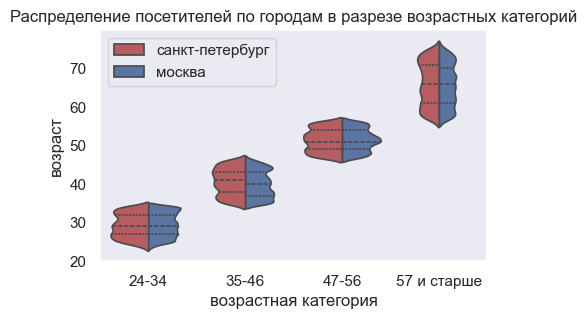

In [246]:
# скрипичная диаграмма
plt.figure(figsize=(5, 3))
ax = sns.violinplot(data=df_copy, x='age_category', y='age',
               hue='city', split=True, inner="quart", palette=['r', 'b'],
               order=sorted(df_copy.age_category.unique()))
plt.legend(loc='upper left')
ax.grid(False)
plt.title('Распределение посетителей по городам в разрезе возрастных категорий')
plt.xlabel('возрастная категория')
plt.ylabel('возраст')
plt.show()

In [247]:
# таблица сопряженности
WF = pd.crosstab(df_copy.age_category, df_copy.city); WF

city,москва,санкт-петербург
age_category,,
24-34,5320,1720
35-46,4362,2075
47-56,2131,1549
57 и старше,4445,3249


In [248]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [249]:
# Проверим связь возрастной категории и города проживания пользователей с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format(chi2, f, prob))

test Statistics: 626.8718833528785
degrees of freedom: 3
p-value: 1.505638470688239e-135



In [250]:
# Полученное значение p-value < 0.05, отклоняем гипотезу Н0.
# Данное отличие является статистически значимым.
# Соответственно, в каждом городе распределение покупателей по возрастным категориям различно.

**Выводы:**
1. По столбчатым и скрипичным диаграммам взаимосвязь между признаками прослеживается. Распределение признаков отличается.
2. Наибольшее число покупателей в Москве относится к категории 24-34 года. Наибольшее число покупателей в СПб относится к категории 57 и старше. Наименьшее число покупателей в Москве и Санкт_Петербурге относится к категории 47-56 лет. 
3. Средние значения возраста по категориям идентичны по обоим городам. Средние и медианные значения возраста по категориям с учетом распределения по городам практически совпадают. Модальные значения отличаются в основном в бОльшую сторону, кроме одного: Москва (категория 35-46 лет)	среднее	40, медиана	40,	мода 35.
4. Взаимосвязь возраста и города проживания пользователей является статистически значимой, т.е. в каждом городе  распределение покупателей по возрастным категориям различно.

### age_category - product

In [251]:
# выберем топ-15 популярных товаров
prod_top = df_copy['product'].value_counts()[:15].index
df_top_15 = df_copy[df_copy['product'].isin(prod_top)]

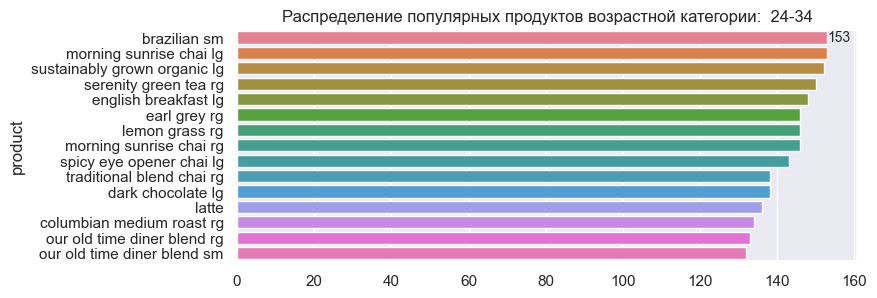

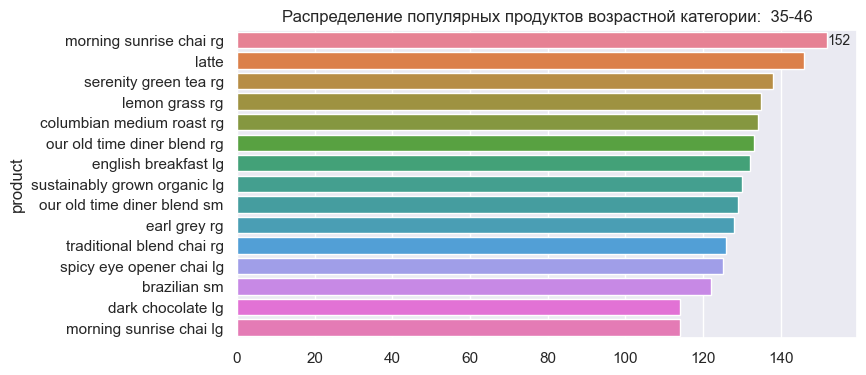

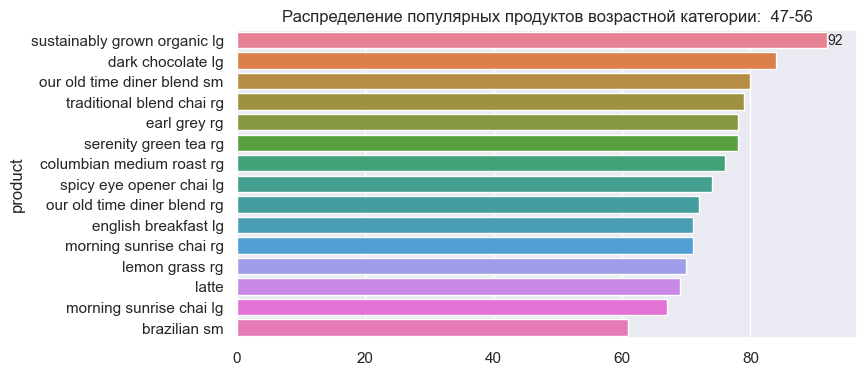

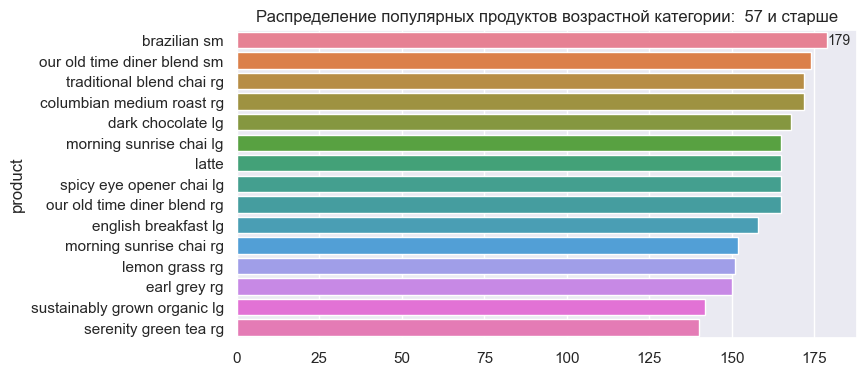

In [252]:
# визуализируем диаграммы топ-15 популярных продуктов для каждой возрастной категории отдельно
plt.figure(figsize=(8, 3))
for age_cat in sorted(df_top_15.age_category.unique()):
    product = df_top_15[df_top_15.age_category==age_cat]['product'].value_counts()
    ax = sns.barplot(y=product.index, hue=product.index, x=product.values)
    ax.bar_label(ax.containers[0], fontsize=10)
    plt.title(f'Распределение популярных продуктов возрастной категории:  {age_cat}')
    plt.show()

In [253]:
# таблица сопряженности
WF = pd.crosstab(df_top_15['product'], df_top_15.age_category); WF

age_category,24-34,35-46,47-56,57 и старше
product,,,,
brazilian sm,153,122,61,179
columbian medium roast rg,134,134,76,172
dark chocolate lg,138,114,84,168
earl grey rg,146,128,78,150
english breakfast lg,148,132,71,158
latte,136,146,69,165
lemon grass rg,146,135,70,151
morning sunrise chai lg,153,114,67,165
morning sunrise chai rg,146,152,71,152


In [254]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [255]:
# Проверим связь выбора товаров и возрастной категории посетителей с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format(chi2, f, prob))

test Statistics: 38.098407392668676
degrees of freedom: 42
p-value: 0.6429095253217868



In [256]:
# Полученное значение p-value > 0.05, принимаем гипотезу Н0.
# Данное отличие является статистически не значимым.
# Соответственно, продукты, которые предпочитают посетители, не зависят от их возрастной категории.

**Выводы:**
1. В каждой возрастной категории присутствуют топ-15 популярных продуктов.
2. Топ-3 продуктов для каждой возрастной категории: 24-34 - 'brazilian sm', 'morning sunrise chai rg', 'sustainably grown organic lg'; 35-46 - 'morning sunrise chai rg', 'latte', 'serenity green tea rg'; 47-56 - 'sustainably grown organic lg', 'dark chocolate lg', 'our old time diner blend sm'; 57 и старше - 'brazilian sm', 'our old time diner blend sm', 'traditional blend chai rg'. Стоит отметить, что 'brazilian sm' в топ-3 2-х категорий: 24-34 и 57 и старше; 'morning sunrise chai rg' в топ-3 2-х категорий: 24-34 и 35-46; 'sustainably grown organic lg' в топ-3 2-х категорий: 24-34 и 47-56; 'our old time diner blend sm' в топ-3 2-х категорий: 47-56 и 57 и старше.
3. Взаимосвязь продуктов, которые популярны у посетителей, и их возрастной категории является статистически не значимой, т.е. продукты, которые предпочитают посетители, не зависят от их возрастной категории.


### age_category - category

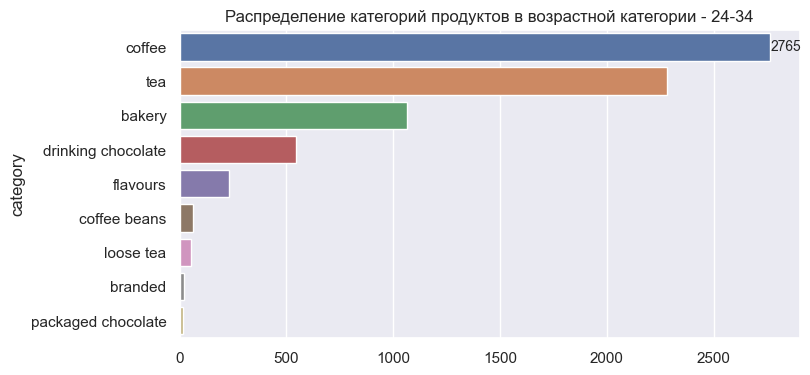

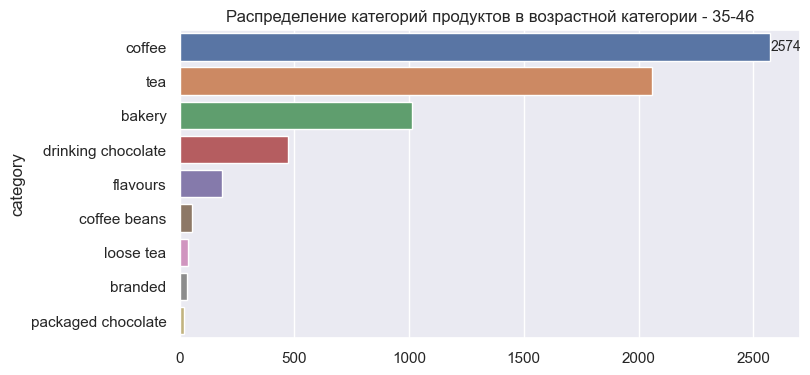

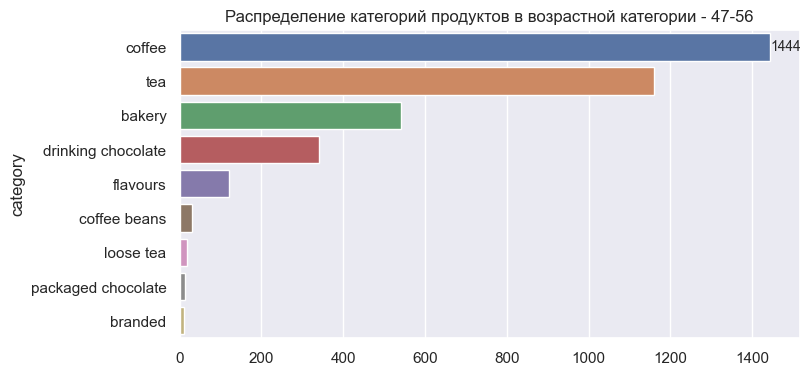

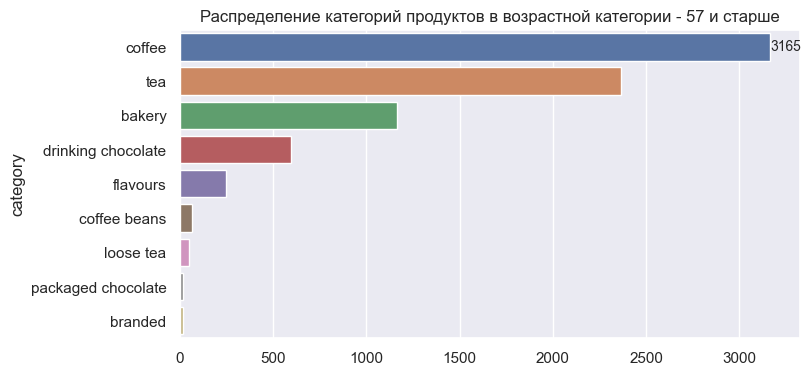

In [257]:
# визуализируем диаграммы категорий продуктов для каждой возрастной категории отдельно
for age_cat in sorted(df_copy.age_category.unique()):
    category = df_copy[df_copy.age_category==age_cat]['category'].value_counts()
    ax = sns.barplot(y=category.index, hue=category.index, x=category.values)
    ax.bar_label(ax.containers[0], fontsize=10)
    plt.title(f'Распределение категорий продуктов в возрастной категории - {age_cat}')
    plt.show()

In [258]:
# таблица сопряженности
WF=pd.crosstab(df_copy['category'], df_copy.age_category); WF

age_category,24-34,35-46,47-56,57 и старше
category,,,,
bakery,1063,1011,542,1164
branded,21,31,11,19
coffee,2765,2574,1444,3165
coffee beans,64,54,30,68
drinking chocolate,544,474,341,596
flavours,230,183,120,249
loose tea,52,34,19,50
packaged chocolate,17,18,12,20
tea,2284,2058,1161,2363


In [259]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [260]:
# Проверим связь категорий продуктов и возрастной категории покупателей с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format( chi2, f, prob))

test Statistics: 34.13388169520479
degrees of freedom: 24
p-value: 0.08231763793889008



In [261]:
# Полученное значение p-value > 0.05, принимаем гипотезу Н0.
# Отличие является статистически не значимым.
# Соответственно, выбор категории продуктов не зависит от возрастной категории посетителей.

**Выводы:**
1. Топ-5 категорий продуктов, которые популярны у всех возрастных категорий посетителей: 'coffee', 'tea', 'bakery','drinking chocolate', 'flavours'. Меньше всего покупают из категорий 'packaged chocolate' и 'branded'.
2. Во всех возрастных категориях похожее распределение категорий товаров.
3. Взаимосвязь категории продукции и возрастной категории посетителей является статистически не значимой, т.е. категория, товары из которой предпочитают посетители, не зависит от их возрастной категории.

### gender - product

In [262]:
# выберем покупателей, указавших пол и 15 самых популярных товаров
gender = ['женский', 'мужской']
prod_top = df_copy['product'].value_counts()[:15].index
df_top_prod_gen = df_copy[df_copy.gender.isin(gender) & df_copy['product'].isin(prod_top)]

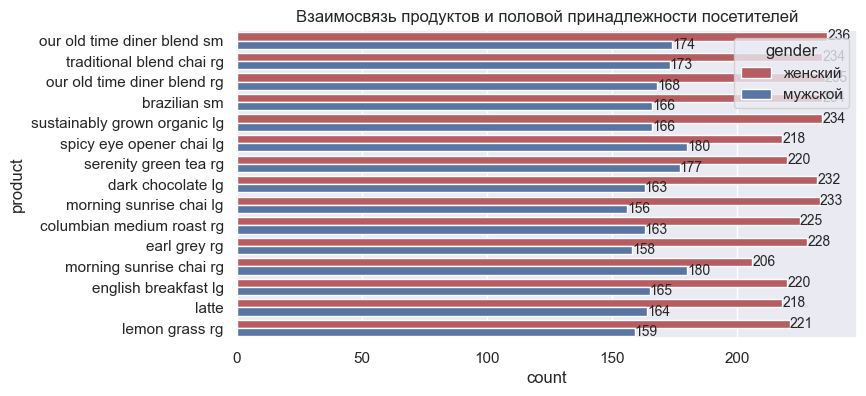

In [263]:
ax = sns.countplot(data=df_top_prod_gen, y='product', hue='gender', palette=['r', 'b'],
                  order=df_top_prod_gen.groupby('product')['gender'].describe().sort_values(by='count', ascending=False).index)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь продуктов и половой принадлежности посетителей')
plt.show()

In [264]:
# таблица сопряженности
WF=pd.crosstab(df_top_prod_gen['product'], df_top_prod_gen.gender); WF

gender,женский,мужской
product,,
brazilian sm,234,166
columbian medium roast rg,225,163
dark chocolate lg,232,163
earl grey rg,228,158
english breakfast lg,220,165
latte,218,164
lemon grass rg,221,159
morning sunrise chai lg,233,156
morning sunrise chai rg,206,180


In [265]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [266]:
# Проверим связь половой принадлежности покупателей и товаров с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format( chi2, f, prob))

test Statistics: 6.749665419032508
degrees of freedom: 14
p-value: 0.9439315402276108



In [267]:
# Полученное значение p-value > 0.05, принимаем гипотезу Н0.
# Отличие является статистически не значимым.
# Соответственно, выбор товара не зависит от половой принадлежности посетителей.

**Выводы:**
1. Женщин немного больше, чем мужчин. Связь продуктов, которые покупают посетители, с их половой принадлежностью по графикам не прослеживается. Распределения признаков похожи.
2. Лидером у женщин является - 'our old time diner blend sm'. У мужчин - 'spicy eye opener chai lg' и 'morning sunrise chai rg'.
3. Взаимосвязь покупаемых товаров и половой принадлежности посетителей не является статистически значимой.

### gender - category

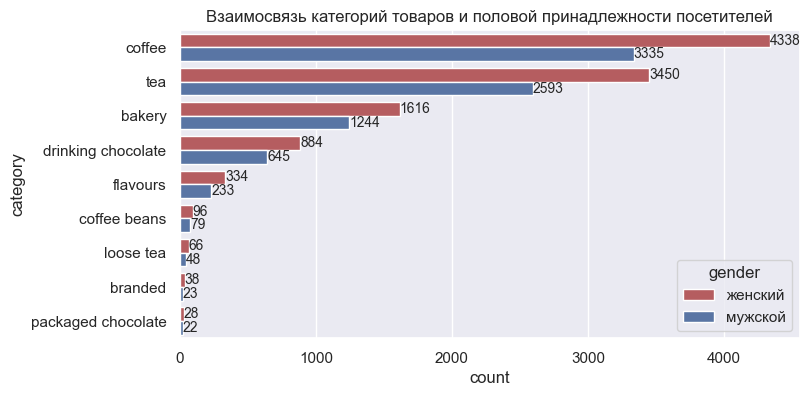

In [268]:
ax = sns.countplot(data=df_copy_gen, y='category', hue='gender', palette=['r', 'b'],
                  order=df_copy_gen.groupby('category')['gender'].describe().sort_values(by='count', ascending=False).index)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь категорий товаров и половой принадлежности посетителей')
plt.show()

In [269]:
# таблица сопряженности
WF=pd.crosstab(df_copy_gen['category'], df_copy_gen.gender); WF

gender,женский,мужской
category,,
bakery,1616,1244
branded,38,23
coffee,4338,3335
coffee beans,96,79
drinking chocolate,884,645
flavours,334,233
loose tea,66,48
packaged chocolate,28,22
tea,3450,2593


In [270]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [271]:
# Проверим связь половой принадлежности покупателей и категорий товаров с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format( chi2, f, prob))

test Statistics: 3.2246477800496933
degrees of freedom: 8
p-value: 0.9194787947414792



In [272]:
# Полученное значение p-value > 0.05, принимаем гипотезу Н0.
# Отличие является статистически не значимым.
# Соответственно, выбор категории товара не зависит от половой принадлежности посетителей.

**Выводы:**
1. Женщин немного больше, чем мужчин. Связь категорий товаров, которые выбирают посетители, с их половой принадлежностью по графикам не прослеживается. Распределения признаков похожи.
2. Топ-5 у женщин и мужчин - 'coffee', 'tea', 'bakery', 'drinking chocolate', 'flavours'. Меньше всего покупают из категорий 'packaged chocolate', 'branded'.
3. Взаимосвязь категорий продуктов и половой принадлежности посетителей не является статистически значимой.

### city - product

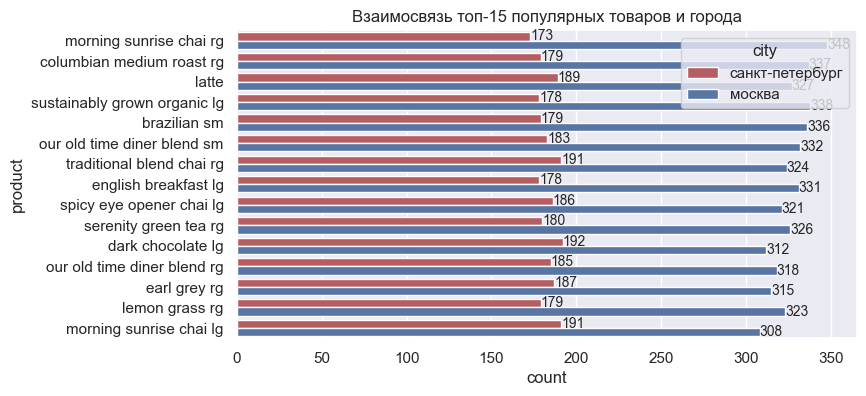

In [273]:
ax = sns.countplot(data=df_top_15, y='product', hue='city', palette=['r', 'b'],
                  order=df_top_15.groupby('product')['city'].describe().sort_values(by='count', ascending=False).index)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь топ-15 популярных товаров и города')
plt.show()

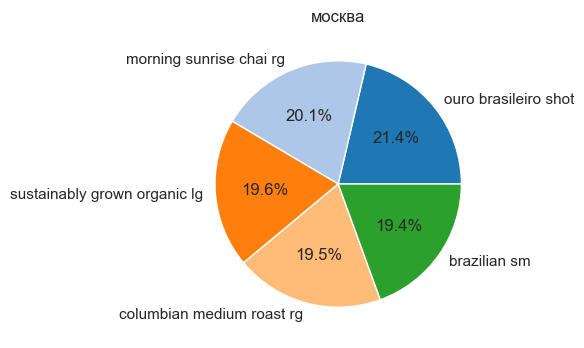

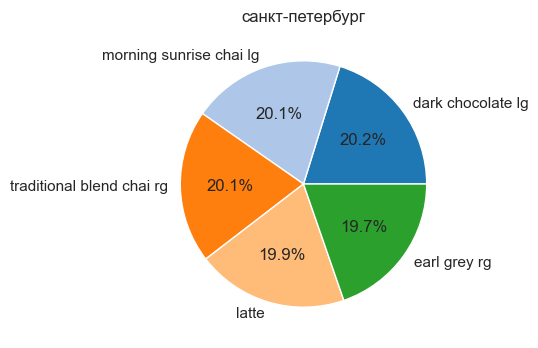

In [274]:
# Дополнительный анализ для сравнения доли каждого продукта из топ-5 в каждом городе,
# так как неравное количество точек продаж может искажать прямые сравнения.

labels = df_top_15['product'].unique()
colors = plt.cm.tab20.colors[:len(labels)]
colors_list = dict(zip(labels, colors))

city_count = df_copy['city'].value_counts().index

for city in city_count:
  df = df_copy[df_copy['city'] == city]

  product_counts = df['product'].value_counts()[:5]
  labels = product_counts.index
  values = product_counts.values

  plt.title(city)
  plt.pie(values, labels=labels, colors=colors, autopct='%.1f%%')
  plt.show()

In [275]:
# таблица сопряженности
WF=pd.crosstab(df_top_15['product'], df_top_15.city); WF

city,москва,санкт-петербург
product,,
brazilian sm,336,179
columbian medium roast rg,337,179
dark chocolate lg,312,192
earl grey rg,315,187
english breakfast lg,331,178
latte,327,189
lemon grass rg,323,179
morning sunrise chai lg,308,191
morning sunrise chai rg,348,173


In [276]:
# частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе)

In [277]:
# Проверим связь популярности товаров и города, где они продаются с помощью критерия ХИ-квадрат.
# Гипотеза Н0: связь между признаками не является статистически значимой.
# Гипотеза H1: связь между признаками является статистически значимой.
# Уровень значимости полагаем равным 0,05.
chi2, prob, f, expected = scipy.stats.chi2_contingency(WF)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"
print(output.format( chi2, f, prob))

test Statistics: 6.361915647167809
degrees of freedom: 14
p-value: 0.9565288231950551



In [278]:
# Полученное значение p-value > 0.05, принимаем гипотезу Н0.
# Отличие является статистически не значимым.
# Соответственно, популярность продукта не зависит от города.

**Выводы:**
1. По столбчатой диаграмме судить о связи популярности продуктов и города сложно, так как количество продаж в городах отличается из-за разного количества точек продаж. Распределение признаков схожи.
2. Относительное распределение популярности топ-5 продуктов по городам примерно одинаковое.
3. Взаимосвязь популярности продуктов и города не является статистически значимой.


### city - category

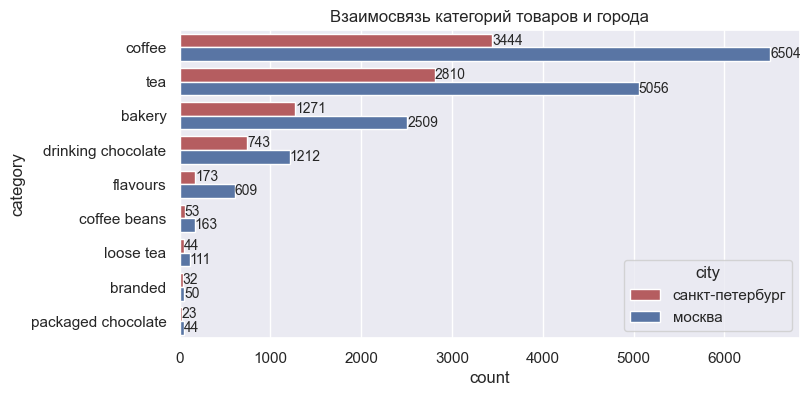

In [279]:
ax = sns.countplot(data=df_copy, y='category', hue='city', palette=['r', 'b'],
                  order=df_copy.groupby('category')['city'].describe().sort_values(by='count', ascending=False).index)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь категорий товаров и города')
plt.show()

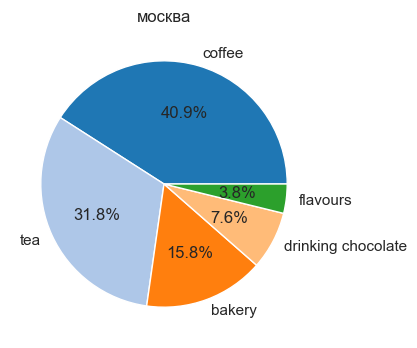

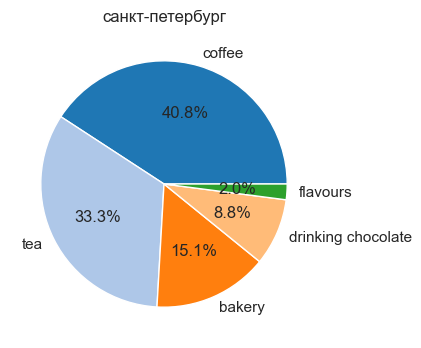

In [280]:
# Дополнительный анализ для сравнения доли каждой категории продуктов из топ-5 в каждом городе,
# так как неравное количество точек продаж может искажать прямые сравнения.

labels = df_copy['category'].unique()
colors = plt.cm.tab20.colors[:len(labels)]
colors_list = dict(zip(labels, colors))

city_count = df_copy['city'].value_counts().index

for city in city_count:
  df = df_copy[df_copy['city'] == city]

  category_counts = df['category'].value_counts()[:5]
  labels = category_counts.index
  values = category_counts.values

  plt.title(city)
  plt.pie(values, labels=labels, colors=colors, autopct='%.1f%%')
  plt.show()

In [281]:
# так как у нас дисбалансные данные (2 точки продаж в Москве и 1 - в СПб), то прямое сравнение не корректно.
# а вот при визуальном сравнении по относительным частотам (пропорциям) видим, что зависимости нет

In [282]:
# таблица сопряженности
WF=pd.crosstab(df_copy['category'], df_copy.city); WF

city,москва,санкт-петербург
category,,
bakery,2509,1271
branded,50,32
coffee,6504,3444
coffee beans,163,53
drinking chocolate,1212,743
flavours,609,173
loose tea,111,44
packaged chocolate,44,23
tea,5056,2810


**Частоты в таблице сопряженности удовлетворяют условиям применения критерия хи-квадрат Пирсона (>5 в группе),
но мы видим четкую разницу в ~2 раза между городами.
не имеет смысла подтверждать гипотезу с помощью критерия ХИ-квадрат, так как получим ложное подтверждение Н1.**

**Выводы:**
1. По столбчатой диаграмме судить о связи популярности категорий товаров и города сложно, так как количество продаж в городах отличается из-за разного количества точек продаж. Распределение признаков схожи.
2. Относительное распределение популярности топ-5 категорий товаров по городам одинаковое.
3. Взаимосвязь популярности категорий товаров и города не является статистически значимой.


# **5. Evaluation / Общие выводы и рекомендации**

**Аналитические цели:**
1. изучить распределение и структуру продаж сети кофеен
2. определить наиболее прибыльные и популярные виды продукции
3. выявить основные категории клиентов

## **I. Общие выводы по датасету**
1. Был представлен датасет с данными о транзакциях и клиентах сети кофеен Заказчика, находящихся в Москве и Санкт_Петербурге: файл в формате csv, содержащий `24909 строк (объектов) и 6 столбцов (признаков)`.
2. Предобработка данных включала в себя: исключение нерелевантных признаков и объектов, дубликатов, распаковку и форматирование данных, расчет дополнительных признаков.
3. По итогу предобработки сохранен датасет, содержащий `24852 объекта, 10 признаков` для последующего анализа в формате xlsx (coffee_shop_hard_clean.xlsx)
4. Дополнительно в процессе анализа была произведена группировка значений возраста по 4 категориям.

## **II. Распределение и структура продаж сети кофеен**
1. **Характеристики продаж:**
* чаще всего в чеке 1 товар, реже 2, совсем редко 3 и 4.
* средняя сумма чека ~300 руб., медианное значение 243.75 руб. 
* сумма 90% чеков не превышает 487.5 руб.
* относительное распределение количества продаж и прибыли в трех кофейнях одинаковое.
* относительное распределение количества продаж и прибыли в Москве и СПб примерно равно, учитывая разницу в количестве кофеен в этих городах.
2. **Зависимости:**
* чем моложе посетители, тем больше прибыли они принесли.

## **III. Наиболее прибыльные и популярные виды продукции**
1. **Наиболее прибыльные виды продукции:**
* наиболее прибыльная категория товаров - coffee, принесла 2_962_352.25 руб. В топ-5 категорий товаров доля прибыли coffee составила 41.5%.
* самый прибыльный товар - sustainably grown organic lg, принес 237_428.75 руб.
* топ-20 самых прибыльных товаров: 'sustainably grown organic lg', 'dark chocolate lg', 'latte rg', 'morning sunrise chai lg', 'latte', 'cappuccino lg', 'sustainably grown organic rg', 'cappuccino', 'ethiopia lg', 'jamaican coffee river lg', 'brazilian lg', 'dark chocolate rg', 'spicy eye opener chai lg', 'serenity green tea lg', 'brazilian rg', 'english breakfast lg', 'ethiopia rg', 'jamaican coffee river rg', 'traditional blend chai lg', 'columbian medium roast lg'.
2. **Наиболее популярные виды продукции:**
* самая популярная категория - coffee, товары из этой категории купили 9948 раз. В топ-5 категорий товаров доля coffee составила 40.9%.
* самый популярный товар - morning sunrise chai rg, купили 521 раз.
* топ-20 самых популярных товаров: 'morning sunrise chai rg', 'columbian medium roast rg', 'latte', 'sustainably grown organic lg', 'traditional blend chai rg', 'brazilian sm', 'our old time diner blend sm', 'english breakfast lg', 'spicy eye opener chai lg', 'serenity green tea rg', 'dark chocolate lg', 'our old time diner blend rg', 'lemon grass rg', 'earl grey rg', 'morning sunrise chai lg', 'brazilian rg', 'english breakfast rg', 'sustainably grown organic rg', 'serenity green tea lg', 'chocolate croissant'
3. **Самые прибыльные и одновременно популярные товары:**
* 'brazilian rg', 'spicy eye opener chai lg', 'english breakfast lg', 'latte', 'dark chocolate lg', 'sustainably grown organic rg', 'sustainably grown organic lg', 'serenity green tea lg', 'morning sunrise chai lg'.
4. **Наименее прибыльные и одновременно не популярные товары:**
* 'i need my bean! diner mug', 'espresso roast', 'sustainably grown organic', 'primo espresso roast', 'traditional blend chai', 'peppermint', 'lemon grass', 'spicy eye opener chai', 'english breakfast', 'morning sunrise chai', 'guatemalan sustainably grown', 'columbian medium roast', 'earl grey', 'serenity green tea', 'dark chocolate', 'chili mayan'.

## **IV. Основные категории клиентов**
1. ***Возраст и половая принадлежность:***
* разброс от 24 до 75 лет.
* возраст 75% пользователей - не старше 60 лет, что свидетельствует о том, что большее число посетителей кофеен - в основном, активное трудоспособное население.
* большая часть посетителей (из указавших пол) - женщины (44%).
* не указан пол в 23.3% наблюдений.
* среднее и медианное значения возраста по полу равны, для мужчин составляет 51 год, для женщин 49 лет.
* после разделения посетителей на 4 группы по возрасту ("24-34", "35-46", "47-56", "57 и выше"), стало очевидно, что больше всего посетителей в категории "57 лет и старше" (31%), далее в категории "24-34 года" (28%), "35-46 лет" (26%), "47-56 лет" (15%).
* средние и наиболее часто встречающиеся значения в каждой возрастной категории: категория "24-34" (29 и 34 года), категория "35-46" (40 и 44 года), категория "47-56" (51 и 51 год), категория "57 и выше" (66 и 68 лет).
* во всех возрастных категориях женщин больше, чем мужчин.
* возраст посетителей отличается в зависимости от половой принадлежности (как при анализе по годам, так и по возрастным категориям).
2. **Город:**
* средний возраст посетителей в Москве - 45 лет, в СПБ - 50 лет
* медианный возраст посетителей в Мосвке - 42 года, в СПб - 50 лет
* медианные значения возраста посетителей женского пола, проживающих в Москве и Санкт-Петербурге, совпадают и составляют 49 лет. Медианные значения возраста посетителей мужского пола, проживающих в Москве и Санкт-Петербурге, почти совпадают и составляют 52 и 51 год соответственно.
* наибольшее число посетителей в Москве относится к категории "24-34 года". Наибольшее число посетителей в СПб относится к категории "57 и старше". Наименьшее число посетителей в Москве и Санкт-Петербурге относится к категории "47-56 лет".
* средние и медианные значения возраста по категориям практически идентичны по обоим городам и составляют 29, 40, 51, 66 лет соответственно. Модальные значения отличаются в основном в бОльшую сторону, кроме одного: Москва (категория "35-46 лет") среднее - 40, медиана - 40, мода - 35.
* в каждом городе распределение посетителей по возрастным категориям различно.
3. **Товары:**
* одни товары покупают более молодые посетители, другие - более зрелые (только при анализе по годам). При анализе по возрастным категориям такой зависимости не выявлено.
* топ-3 популярных товаров в каждой возрастной категории: "24-34" - 'brazilian sm', 'morning sunrise chai rg', 'sustainably grown organic lg'; "35-46" - 'morning sunrise chai rg', 'latte', 'serenity green tea rg'; "47-56" - 'sustainably grown organic lg', 'dark chocolate lg', 'our old time diner blend sm'; "57 и старше" - 'brazilian sm', 'our old time diner blend sm', 'traditional blend chai rg'. Стоит отметить, что 'brazilian sm' в топ-3 2-х категорий: "24-34" и "57 и старше"; 'morning sunrise chai rg' в топ-3 2-х категорий: "24-34" и "35-46"; 'sustainably grown organic lg' в топ-3 2-х категорий: "24-34" и "47-56"; 'our old time diner blend sm' в топ-3 2-х категорий: "47-56" и "57 и старше".
* самый популярный товар у женщин - 'our old time diner blend sm'. Самые популярные товары у мужчин - 'spicy eye opener chai lg' и 'morning sunrise chai rg'.
* товары, которые предпочитают посетители, не зависят от их половой принадлежности и от города проживания.
4. **Категории товаров:**
* топ-5 категорий продуктов, которые популярны у всех возрастных категорий посетителей обоего пола: 'coffee', 'tea', 'bakery','drinking chocolate', 'flavours'. Меньше всего покупают из категорий 'packaged chocolate' и 'branded'.
* во всех возрастных категориях похожее распределение категорий товаров.
* выбор категории товаров не зависит от пола, возраста (как при анализе по годам, так и по возрастным категориям) и города.
5. **Основные категории клиентов:**
* основные категории посетителей В Москве  — это категории 24-34 года и 35-46 года.
* основная категория посетителей в Санкт-Петербурге - 57 лет и старше.

## **IV. Рекомендации:**
1. **Целевые группы посетителей**
* В Москве основной контингент посетителей — это категории 24-34 года (28%) и 35-46 года (26%), молодая и активная аудитория. Новые кофейни стоит ориентировать на стиль и предложения, привлекательные для этой возрастной группы.
* В Санкт-Петербурге доминирует категория 57 лет и старше (31%), более зрелая аудитория. Здесь важна комфортная атмосфера, возможно, более спокойный интерьер.
2. **Ассортимент и самые прибыльные продукты**
* В обеих локациях основное внимание следует уделить наиболее прибыльной и популярной категории — coffee (около 41% прибыли и продаж). Рекомендуется выстроить меню новых кофеен с учётом самый прибыльных и популярных товаров brazilian rg, spicy eye opener chai lg, english breakfast lg, latte, dark chocolate lg, sustainably grown organic rg, sustainably grown organic lg, serenity green tea lg, morning sunrise chai lg.
* Женщинам особенно нравятся our old time diner blend sm, мужчинам — spicy eye opener chai lg и morning sunrise chai rg — учесть предпочтения по полу в маркетинге и акциях.
3. **Локация и возрастной контингент**
* Для новых кофеен в Москве стоит выбирать места с высокой концентрацией молодых и активных людей (например, вблизи офисных центров, вузов, торговых центров).
* В Санкт-Петербурге — ориентироваться на районы с большой долей зрелого населения. Дополнительно провести анализ для поиска таких районов.
4. **Маркетинговые и продуктовые стратегии**
* Разработать акции и рекламные кампании, направленные на популяризацию топовых продуктов.
* Акцентировать внимание на категории coffee и tea (первые позиции в топ-5 категорий по всем группам).
* Использовать данные по возрастным категориям для сегментированного маркетинга (например, соцсети для молодых в Москве, локальные СМИ и события для более зрелых в СПб).
5. **Анализ и отказ от неэффективных товаров**
* Исключить из ассортимента или снизить долю продаж низкоприбыльных и не популярных товаров: i need my bean! diner mug, espresso roast, sustainably grown organic, primo espresso roast, traditional blend chai, peppermint, lemon grass, spicy eye opener chai, english breakfast, morning sunrise chai, guatemalan sustainably grown, columbian medium roast, earl grey, serenity green tea, dark chocolate, chili mayan.
* Фокусироваться на ассортименте, доказавшем спрос и прибыльность.
6. **Мониторинг спроса и адаптация**
* Запустить систему мониторинга продаж в новых кофейнях для своевременной корректировки ассортимента.
* Собрать обратную связь от посетителей для улучшения сервиса и предложения товаров.
* Готовиться к сезонным и региональным изменениям в спросе.